In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [ ]:
!pip install fastparquet

   ---------------------------------------- 0.0/673.2 kB ? eta -:--:--
   ------------------------------- -------- 524.3/673.2 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 673.2/673.2 kB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 2.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.4 MB/s  0:00:00

   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
data = pd.read_parquet("data/block1_train.parquet", engine='fastparquet')

In [20]:
# Kolone sa cenama
price_cols = [col for col in data.columns if col.endswith('_price')]

# Napravi listu kolona koje želiš da prikažeš
columns_to_show = ['payment_frequency'] + price_cols

# Prikaži prvih 100 redova====
display_df = data[columns_to_show][data['payment_frequency']=='monthly'].head(100)

print("Payment frequency i cene za prvih 100 redova:")
print(display_df)

Payment frequency i cene za prvih 100 redova:
    payment_frequency  Insurer_A_price  Insurer_B_price  Insurer_C_price  \
0             monthly         119.7600              NaN              NaN   
1             monthly         233.7925              NaN           258.93   
2             monthly          54.0125            82.39              NaN   
3             monthly         160.8592              NaN           174.81   
4             monthly         121.5292           202.14              NaN   
6             monthly         147.0425           146.24           146.46   
7             monthly          85.0092            72.68            65.67   
8             monthly         147.0425           146.24           146.46   
9             monthly         267.5667           342.28              NaN   
10            monthly         138.3375           219.57              NaN   
11            monthly         267.5667           342.28              NaN   
12            monthly          58.1650    

In [21]:
test = pd.read_parquet("data/block2_test.parquet", engine='fastparquet')

In [23]:
test['payment_frequency'].value_counts()

payment_frequency
monthly    160509
yearly       3583
Name: count, dtype: int64

In [24]:
print("Jedinstvene vrednosti u coverage:")
print(data['coverage'].value_counts())
print(f"\nTip podataka: {data['coverage'].dtype}")

Jedinstvene vrednosti u coverage:
coverage
limited_casco    238176
casco            163742
mtpl             139374
Name: count, dtype: int64

Tip podataka: object


In [25]:
price_cols = [col for col in data.columns if col.endswith('_price')]

print("="*80)
print("STATISTIKA CENA PO COVERAGE TIPU")
print("="*80)

for price_col in price_cols:
    insurer = price_col.replace('_price', '')
    print(f"\n{insurer}:")
    
    stats = data.groupby('coverage')[price_col].agg(['count', 'min', 'mean', 'median', 'max', 'std']).round(2)
    print(stats)

STATISTIKA CENA PO COVERAGE TIPU

Insurer_A:
                count    min    mean  median      max     std
coverage                                                     
casco          156664  13.93  112.90   76.49  4370.41  150.85
limited_casco  231334  12.33   92.37   63.22  4305.92  100.89
mtpl           139374  14.00   86.40   65.22  3644.31   87.26

Insurer_B:
                count    min    mean  median      max    std
coverage                                                    
casco          140963  28.21  116.47   88.10  1252.46  84.24
limited_casco  186607  18.21   88.02   67.00   897.60  69.30
mtpl           108189  15.75   98.30   77.79   798.06  69.66

Insurer_C:
                count    min    mean  median      max    std
coverage                                                    
casco          140269  20.54  112.17   89.45  1095.15  73.80
limited_casco  192485  12.16   82.24   64.05   850.74  60.65
mtpl            98257  14.16   70.56   62.96   360.50  34.15

Insurer_D:

In [34]:
# Izdvoji sve kolone koje počinju sa 'vehicle_'
vehicle_cols = [col for col in data.columns if col.startswith('vehicle_')]

# Izdvoji sve kolone sa cenama
price_cols = [col for col in data.columns if col.endswith('_price')]

print(f"Broj vehicle feature-a: {len(vehicle_cols)}")
print(f"Broj cena (osiguravača): {len(price_cols)}")
print("\nVehicle feature-i:")
print(vehicle_cols[:10])  # Prikaži prvih 10
print("\nOsiguravači:")
print([col.replace('_price', '') for col in price_cols])

Broj vehicle feature-a: 39
Broj cena (osiguravača): 11

Vehicle feature-i:
['vehicle_ownership_duration', 'vehicle_number_plate', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length']

Osiguravači:
['Insurer_A', 'Insurer_B', 'Insurer_C', 'Insurer_D', 'Insurer_E', 'Insurer_F', 'Insurer_G', 'Insurer_H', 'Insurer_I', 'Insurer_J', 'Insurer_K']


In [33]:
vehicle_cols = [col for col in data.columns if col.startswith('vehicle_')]

print("Pre konverzije:")
for col in vehicle_cols[:10]:
    print(f"  {col}: {data[col].dtype}")

# Konvertuj sve vehicle kolone u numeric (errors='coerce' pretvara nekonvertibilno u NaN)
for col in vehicle_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("\nPosle konverzije:")
for col in vehicle_cols[:10]:
    print(f"  {col}: {data[col].dtype}")

Pre konverzije:
  vehicle_ownership_duration: object
  vehicle_number_plate: object
  vehicle_maker: object
  vehicle_model: object
  vehicle_fuel_type: object
  vehicle_engine_size: object
  vehicle_power: object
  vehicle_net_weight: object
  vehicle_gross_weight: object
  vehicle_length: object

Posle konverzije:
  vehicle_ownership_duration: float64
  vehicle_number_plate: float64
  vehicle_maker: float64
  vehicle_model: float64
  vehicle_fuel_type: float64
  vehicle_engine_size: float64
  vehicle_power: float64
  vehicle_net_weight: int64
  vehicle_gross_weight: float64
  vehicle_length: float64


In [35]:
numeric_vehicle_cols = data[vehicle_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"\nBroj numeričkih vehicle feature-a: {len(numeric_vehicle_cols)}")
print("Numerički vehicle feature-i:")
print(numeric_vehicle_cols)


Broj numeričkih vehicle feature-a: 39
Numerički vehicle feature-i:
['vehicle_ownership_duration', 'vehicle_number_plate', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_primary_color', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'vehicle_last_registration_date', 'vehicle_years_since_country_first_registration', 'vehicle_inspection_report_date', 'vehicle_inspection_expiry_date', 'vehicle_inspection_number_of_deficiencies_found', 'vehicle_year_of_last_odometer_report', 'vehicle_odometer_verdict_code', 'vehicle_planned_an

In [39]:


# Izdvoji sve vehicle kolone
vehicle_cols = [col for col in data.columns if col.startswith('vehicle_')]

# Konvertuj sve vehicle kolone u numeric
for col in vehicle_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Ponovo izdvoji numeričke vehicle kolone (one koje imaju bar neku vrednost)
numeric_vehicle_cols = []
for col in vehicle_cols:
    if data[col].notna().sum() > 0:  # Ima bar jednu vrednost
        numeric_vehicle_cols.append(col)

print(f"Numeričkih vehicle feature-a: {len(numeric_vehicle_cols)}")
print(numeric_vehicle_cols[:20])  # Prikaži prvih 20

# Kolone sa cenama
price_cols = [col for col in data.columns if col.endswith('_price')]

# Izračunaj pairwise korelaciju
corr_matrix = pd.DataFrame(index=numeric_vehicle_cols, columns=price_cols)

for vehicle_feat in numeric_vehicle_cols:
    for price_col in price_cols:
        # Ukloni NaN samo za ovaj par
        valid_data = data[[vehicle_feat, price_col]].dropna()
        if len(valid_data) > 10:  # Dovoljno podataka za korelaciju
            corr_matrix.loc[vehicle_feat, price_col] = valid_data[vehicle_feat].corr(valid_data[price_col])
        else:
            corr_matrix.loc[vehicle_feat, price_col] = np.nan

# Konvertuj u float
corr_matrix = corr_matrix.astype(float)

print(f"\nKorelaciona matrica: {corr_matrix.shape}")
print(f"Broj parova sa korelacijom: {corr_matrix.notna().sum().sum()}")

Numeričkih vehicle feature-a: 25
['vehicle_ownership_duration', 'vehicle_number_plate', 'vehicle_model', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age']


c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.


Korelaciona matrica: (25, 11)
Broj parova sa korelacijom: 242


Čista matrica: (22, 11)
Vehicle feature-a: 22
Osiguravača: 11


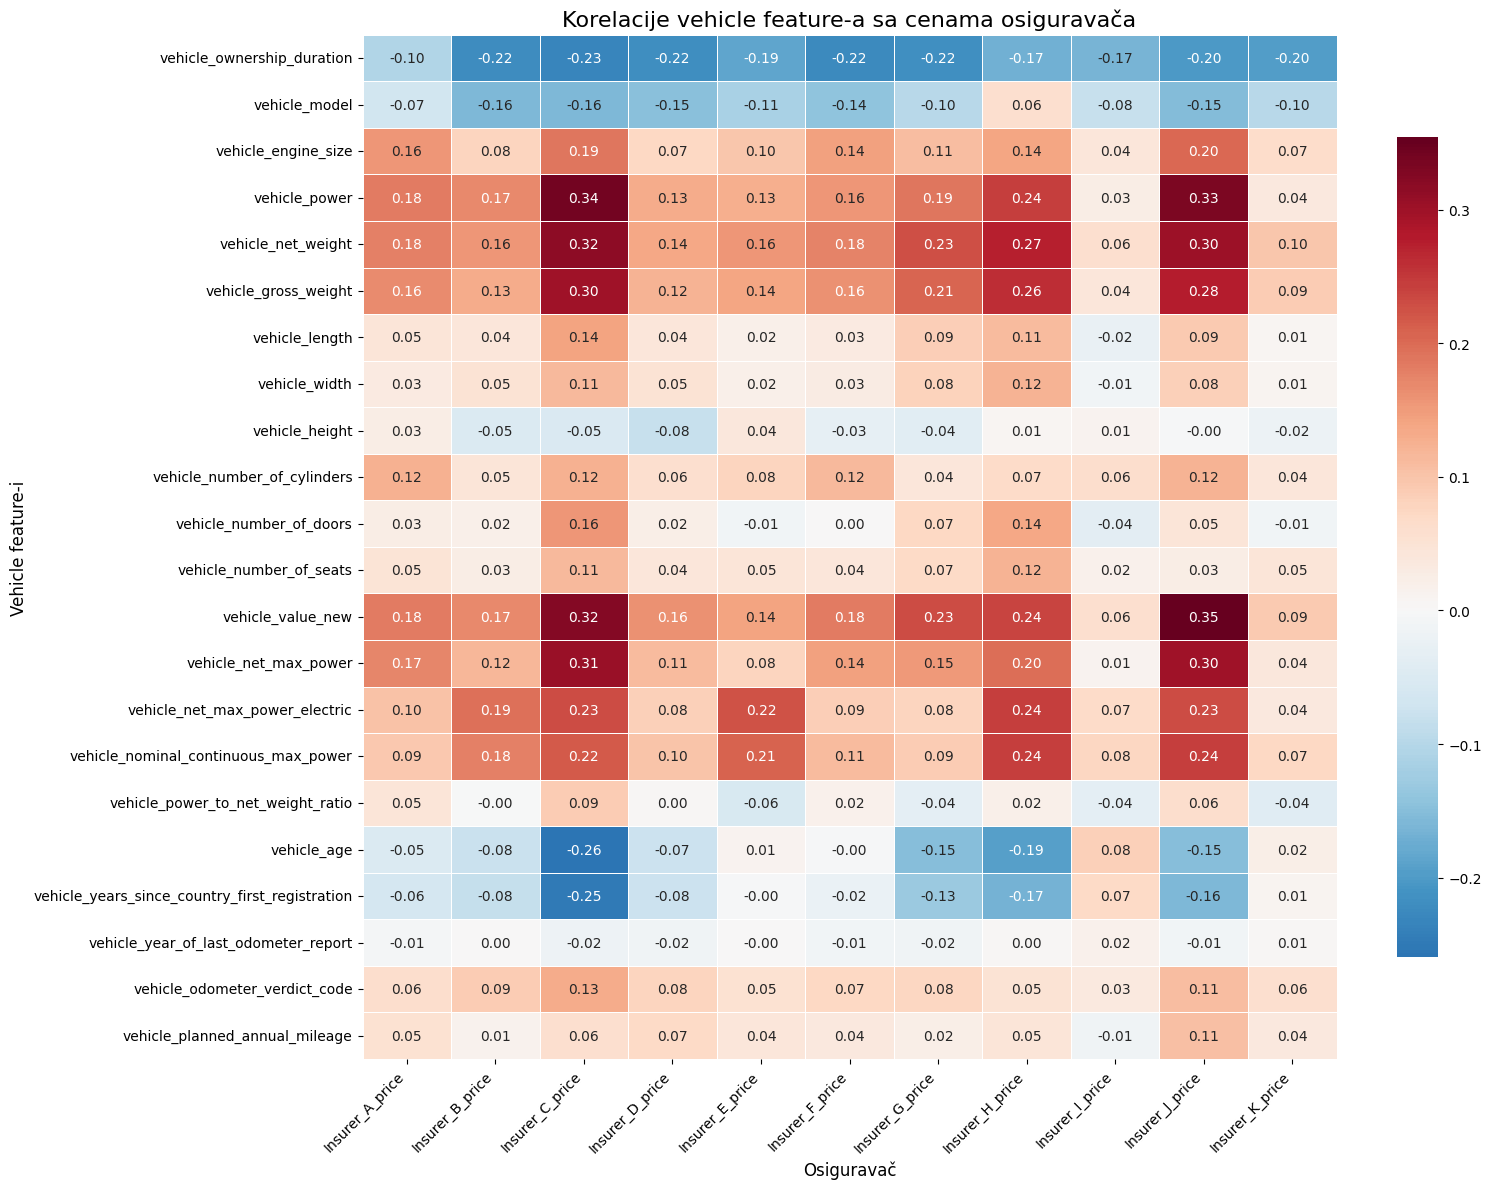

In [49]:

# Ukloni redove koji su potpuno NaN
corr_clean = corr_matrix.dropna(how='all', axis=0)

# Ukloni kolone koje su potpuno NaN
corr_clean = corr_clean.dropna(how='all', axis=1)

print(f"Čista matrica: {corr_clean.shape}")
print(f"Vehicle feature-a: {len(corr_clean)}")
print(f"Osiguravača: {len(corr_clean.columns)}")

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_clean, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=False,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Korelacije vehicle feature-a sa cenama osiguravača', fontsize=16)
plt.xlabel('Osiguravač', fontsize=12)
plt.ylabel('Vehicle feature-i', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('slike/vehicle_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Kolone sa cenama
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,is_driver_owner,usage,second_driver_birthdate,second_driver_claim_free_years,vehicle_maker,vehicle_model,vehicle_fuel_type,vehicle_engine_size,vehicle_power,vehicle_net_weight,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_number_of_wheels,vehicle_primary_color,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_first_registration_date,vehicle_country_first_registration_date,vehicle_last_registration_date,vehicle_years_since_country_first_registration,vehicle_inspection_report_date,vehicle_inspection_expiry_date,vehicle_inspection_number_of_deficiencies_found,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,vehicle_is_imported_within_last_12_months,vehicle_can_be_registered,vehicle_has_open_recall,vehicle_is_marked_for_export,vehicle_is_taxi,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_owner_occupied_houses_ratio,postal_code_rental_houses_ratio,postal_code_houses_owned_by_rental_association_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_within_5_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermar

In [43]:
# Izdvoji sve kolone koje počinju sa 'postal_code_'
postal_cols = [col for col in data.columns if col.startswith('postal_code_')]

print(f"Broj postal_code feature-a: {len(postal_cols)}")
print("\nPostal code feature-i:")
for col in postal_cols[:20]:  # Prikaži prvih 20
    print(f"  {col}")
    
if len(postal_cols) > 20:
    print(f"  ... i još {len(postal_cols)-20} feature-a")

Broj postal_code feature-a: 81

Postal code feature-i:
  postal_code_latitude
  postal_code_longitude
  postal_code_distance_to_border
  postal_code_urban_category
  postal_code_population
  postal_code_households
  postal_code_houses
  postal_code_average_household_size
  postal_code_0_to_15_years_inhabitants_ratio
  postal_code_25_to_45_years_inhabitants_ratio
  postal_code_45_to_65_years_inhabitants_ratio
  postal_code_65_years_and_older_inhabitants_ratio
  postal_code_single_person_households_ratio
  postal_code_multi_person_households_without_children_ratio
  postal_code_two_parent_households_ratio
  postal_code_social_benefit_recipients_ratio
  postal_code_address_density
  postal_code_average_property_value
  postal_code_owner_occupied_houses_ratio
  postal_code_rental_houses_ratio
  ... i još 61 feature-a


In [44]:
for col in postal_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Izdvoji numeričke postal kolone
numeric_postal_cols = []
for col in postal_cols:
    if data[col].notna().sum() > 0:  # Ima bar jednu vrednost
        numeric_postal_cols.append(col)

print(f"\nNumeričkih postal feature-a: {len(numeric_postal_cols)}")
print(numeric_postal_cols[:20])


Numeričkih postal feature-a: 80
['postal_code_latitude', 'postal_code_longitude', 'postal_code_distance_to_border', 'postal_code_urban_category', 'postal_code_population', 'postal_code_households', 'postal_code_houses', 'postal_code_average_household_size', 'postal_code_0_to_15_years_inhabitants_ratio', 'postal_code_25_to_45_years_inhabitants_ratio', 'postal_code_45_to_65_years_inhabitants_ratio', 'postal_code_65_years_and_older_inhabitants_ratio', 'postal_code_single_person_households_ratio', 'postal_code_multi_person_households_without_children_ratio', 'postal_code_two_parent_households_ratio', 'postal_code_social_benefit_recipients_ratio', 'postal_code_address_density', 'postal_code_average_property_value', 'postal_code_owner_occupied_houses_ratio', 'postal_code_rental_houses_ratio']


In [45]:
# Kolone sa cenama
price_cols = [col for col in data.columns if col.endswith('_price')]

# Izračunaj pairwise korelaciju
postal_corr_matrix = pd.DataFrame(index=numeric_postal_cols, columns=price_cols)

for postal_feat in numeric_postal_cols:
    for price_col in price_cols:
        valid_data = data[[postal_feat, price_col]].dropna()
        if len(valid_data) > 10:
            postal_corr_matrix.loc[postal_feat, price_col] = valid_data[postal_feat].corr(valid_data[price_col])
        else:
            postal_corr_matrix.loc[postal_feat, price_col] = np.nan

postal_corr_matrix = postal_corr_matrix.astype(float)

print(f"\nKorelaciona matrica: {postal_corr_matrix.shape}")
print(f"Broj parova sa korelacijom: {postal_corr_matrix.notna().sum().sum()}")


Korelaciona matrica: (80, 11)
Broj parova sa korelacijom: 880


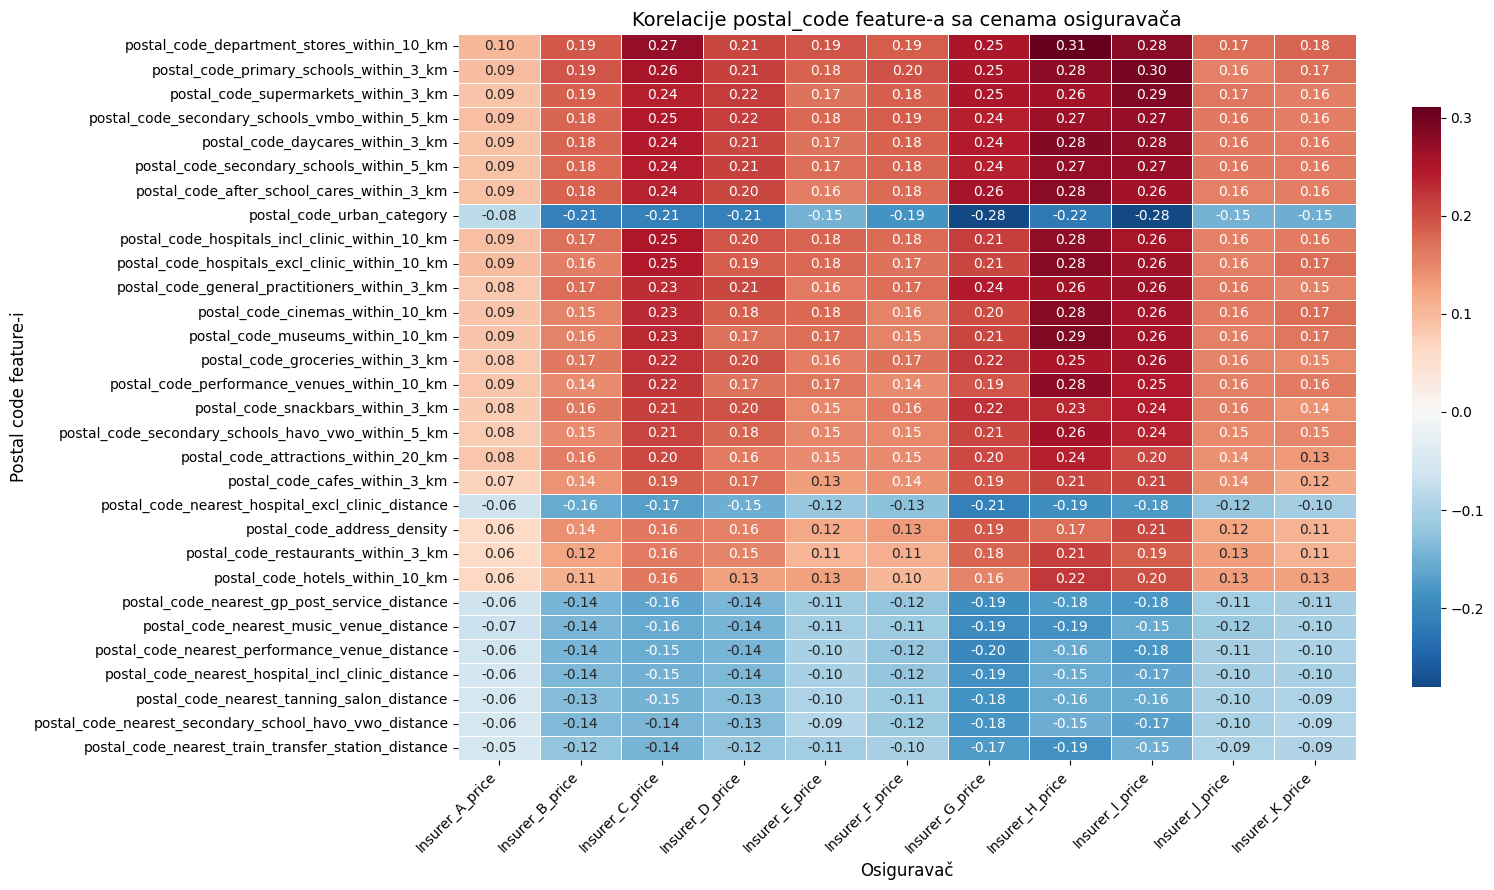

In [48]:
import matplotlib.pyplot as plt
# Ukloni redove i kolone koji su potpuno NaN
postal_corr_clean = postal_corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

if len(postal_corr_clean) > 0 and len(postal_corr_clean.columns) > 0:
    # Ako ima previše redova, uzmi top 30
    if len(postal_corr_clean) > 30:
        # Izračunaj prosečnu apsolutnu korelaciju i uzmi top 30
        avg_corr = postal_corr_clean.abs().mean(axis=1).sort_values(ascending=False)
        top_features = avg_corr.head(30).index.tolist()
        postal_corr_clean = postal_corr_clean.loc[top_features, :]
    
    plt.figure(figsize=(16, max(8, len(postal_corr_clean) * 0.3)))
    sns.heatmap(postal_corr_clean, 
                annot=True, 
                fmt='.2f', 
                cmap='RdBu_r', 
                center=0,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    
    plt.title('Korelacije postal_code feature-a sa cenama osiguravača', fontsize=14)
    plt.xlabel('Osiguravač', fontsize=12)
    plt.ylabel('Postal code feature-i', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('slike/postal_corr_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Nema dovoljno podataka za heatmap")

In [52]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,is_driver_owner,usage,second_driver_birthdate,second_driver_claim_free_years,vehicle_maker,vehicle_model,vehicle_fuel_type,vehicle_engine_size,vehicle_power,vehicle_net_weight,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_number_of_wheels,vehicle_primary_color,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_first_registration_date,vehicle_country_first_registration_date,vehicle_last_registration_date,vehicle_years_since_country_first_registration,vehicle_inspection_report_date,vehicle_inspection_expiry_date,vehicle_inspection_number_of_deficiencies_found,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,vehicle_is_imported_within_last_12_months,vehicle_can_be_registered,vehicle_has_open_recall,vehicle_is_marked_for_export,vehicle_is_taxi,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_owner_occupied_houses_ratio,postal_code_rental_houses_ratio,postal_code_houses_owned_by_rental_association_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_within_5_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermar

In [57]:
target_nulls =  541292
columns_with_target_nulls = data.columns[data.isnull().sum() == target_nulls]

print(f"Kolone sa tačno {target_nulls} null vrednosti:")
print(columns_with_target_nulls.tolist())
print(f"Broj takvih kolona: {len(columns_with_target_nulls)}")

Kolone sa tačno 541292 null vrednosti:
['second_driver_birthdate', 'second_driver_claim_free_years', 'vehicle_maker', 'vehicle_fuel_type', 'vehicle_primary_color', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'vehicle_last_registration_date', 'vehicle_inspection_report_date', 'vehicle_inspection_expiry_date', 'vehicle_is_imported', 'vehicle_is_imported_within_last_12_months', 'vehicle_can_be_registered', 'vehicle_has_open_recall', 'vehicle_is_marked_for_export', 'vehicle_is_taxi', 'postal_code_houses_owned_by_rental_association_ratio']
Broj takvih kolona: 17


In [56]:
# Pronađi kolone gde jedna vrednost dominira (>99%)
threshold = 0.99  # 99%
high_dominance_cols = []

for col in data.columns:
    if data[col].dtype in ['object', 'category'] or data[col].nunique() < 100:  # Za kategorijalne
        value_counts = data[col].value_counts(normalize=True)
        if len(value_counts) > 0 and value_counts.iloc[0] > threshold:
            high_dominance_cols.append({
                'col': col,
                'dominant_value': value_counts.index[0],
                'percentage': value_counts.iloc[0] * 100
            })

print("\n" + "="*80)
print(f"KOLONE SA DOMINANTNOM VREDNOŠĆU (> {threshold*100}%)")
print("="*80)
for item in high_dominance_cols:
    print(f"  {item['col']:50} -> '{item['dominant_value']}' ({item['percentage']:.2f}%)")


KOLONE SA DOMINANTNOM VREDNOŠĆU (> 99.0%)
  is_driver_owner                                    -> 'yes' (99.92%)
  usage                                              -> 'private_use' (100.00%)
  vehicle_number_of_wheels                           -> '4' (100.00%)
  vehicle_inspection_number_of_deficiencies_found    -> '1.0' (100.00%)
  Insurer_D_deductible                               -> '0.0' (99.84%)
  Insurer_F_deductible                               -> '0.0' (99.06%)
  Insurer_I_deductible                               -> '0.0' (99.34%)


In [59]:
data.shape

(541292, 155)

In [60]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,is_driver_owner,usage,second_driver_birthdate,second_driver_claim_free_years,vehicle_maker,vehicle_model,vehicle_fuel_type,vehicle_engine_size,vehicle_power,vehicle_net_weight,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_number_of_wheels,vehicle_primary_color,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_first_registration_date,vehicle_country_first_registration_date,vehicle_last_registration_date,vehicle_years_since_country_first_registration,vehicle_inspection_report_date,vehicle_inspection_expiry_date,vehicle_inspection_number_of_deficiencies_found,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,vehicle_is_imported_within_last_12_months,vehicle_can_be_registered,vehicle_has_open_recall,vehicle_is_marked_for_export,vehicle_is_taxi,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_owner_occupied_houses_ratio,postal_code_rental_houses_ratio,postal_code_houses_owned_by_rental_association_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_within_5_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermar

In [61]:
# Feature-i koji govore o uvozu
import_features = [
    'vehicle_is_imported',                           # Da li je vozilo uvezeno
    'vehicle_is_imported_within_last_12_months',    # Da li je uvezeno u poslednjih 12 meseci
    'vehicle_country_first_registration_date',      # Datum prve registracije u zemlji
    'vehicle_years_since_country_first_registration' # Godine od prve registracije u zemlji
]

print("Feature-i za uvoz:")
for col in import_features:
    if col in data.columns:
        print(f"  {col}:")
        print(f"    - Tip: {data[col].dtype}")
        print(f"    - Unique vrednosti: {data[col].nunique()}")
        print(f"    - Primeri: {data[col].head(3).tolist()}")

Feature-i za uvoz:
  vehicle_is_imported:
    - Tip: float64
    - Unique vrednosti: 0
    - Primeri: [nan, nan, nan]
  vehicle_is_imported_within_last_12_months:
    - Tip: float64
    - Unique vrednosti: 0
    - Primeri: [nan, nan, nan]
  vehicle_country_first_registration_date:
    - Tip: float64
    - Unique vrednosti: 0
    - Primeri: [nan, nan, nan]
  vehicle_years_since_country_first_registration:
    - Tip: float64
    - Unique vrednosti: 41
    - Primeri: [7.0, 8.0, 9.0]


In [62]:
print("\n" + "="*80)
print("STANJE NULL VREDNOSTI ZA FEATURE-E O UVOZU")
print("="*80)

for col in import_features:
    if col in data.columns:
        null_count = data[col].isna().sum()
        null_pct = (null_count / len(data)) * 100
        print(f"{col:45} {null_count:8} null ({null_pct:.2f}%)")


STANJE NULL VREDNOSTI ZA FEATURE-E O UVOZU
vehicle_is_imported                             541292 null (100.00%)
vehicle_is_imported_within_last_12_months       541292 null (100.00%)
vehicle_country_first_registration_date         541292 null (100.00%)
vehicle_years_since_country_first_registration    21451 null (3.96%)


In [63]:
# Izračunaj da li je vozilo verovatno uvezeno
if 'vehicle_years_since_country_first_registration' in data.columns and 'vehicle_age' in data.columns:
    # vehicle_age - starost vozila
    # vehicle_years_since_country_first_registration - godine od registracije u zemlji
    
    # Ako je vozilo starije nego što je registrovano u zemlji, znači da je uvezeno
    data['inferred_imported'] = data['vehicle_years_since_country_first_registration'] < data['vehicle_age']
    
    print("\nInferirani uvoz na osnovu starosti:")
    print(f"  Verovatno uvezeno: {data['inferred_imported'].sum()}")
    print(f"  Verovatno domaće: {(~data['inferred_imported']).sum()}")


Inferirani uvoz na osnovu starosti:
  Verovatno uvezeno: 150278
  Verovatno domaće: 391014


C:\Users\zKi\AppData\Local\Temp\ipykernel_23992\3622618734.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['inferred_imported'] = data['vehicle_years_since_country_first_registration'] < data['vehicle_age']


In [65]:
print("="*80)
print("STANJE PRE POPUNJAVANJA")
print("="*80)

if 'vehicle_is_imported' in data.columns:
    null_before = data['vehicle_is_imported'].isna().sum()
    print(f"vehicle_is_imported - null: {null_before} ({null_before/len(data)*100:.2f}%)")
    
    # Proveri da li ima vrednosti
    if data['vehicle_is_imported'].notna().sum() > 0:
        print(f"  Postojeće vrednosti: {data['vehicle_is_imported'].value_counts().to_dict()}")
    else:
        print(f"  NEMA NIJEDNU VREDNOST - biće kreiran novi feature")

STANJE PRE POPUNJAVANJA
vehicle_is_imported - null: 541292 (100.00%)
  NEMA NIJEDNU VREDNOST - biće kreiran novi feature


In [66]:
def create_imported_feature(data):
    """
    Kreira/popunjava vehicle_is_imported na osnovu:
    - vehicle_years_since_country_first_registration
    - vehicle_age
    """
    
    # Proveri da li imamo potrebne kolone
    if 'vehicle_years_since_country_first_registration' not in data.columns:
        print("❌ Nedostaje vehicle_years_since_country_first_registration")
        return data
    
    if 'vehicle_age' not in data.columns:
        print("❌ Nedostaje vehicle_age")
        return data
    
    print("\n" + "="*80)
    print("POPUNJAVANJE vehicle_is_imported")
    print("="*80)
    
    # 1. Popuni NaN u vehicle_age ako ima
    if data['vehicle_age'].isna().sum() > 0:
        median_age = data['vehicle_age'].median()
        data['vehicle_age'] = data['vehicle_age'].fillna(median_age)
        print(f"Popunjeno NaN u vehicle_age sa medianom: {median_age}")
    
    # 2. Popuni NaN u vehicle_years_since_country_first_registration ako ima
    if data['vehicle_years_since_country_first_registration'].isna().sum() > 0:
        median_years = data['vehicle_years_since_country_first_registration'].median()
        data['vehicle_years_since_country_first_registration'] = data['vehicle_years_since_country_first_registration'].fillna(median_years)
        print(f"Popunjeno NaN u vehicle_years_since_country_first_registration sa medianom: {median_years}")
    
    # 3. Definiši da li je vozilo uvezeno
    # Ako je vehicle_years_since_country_first_registration < vehicle_age, vozilo je uvezeno
    is_imported = (data['vehicle_years_since_country_first_registration'] < data['vehicle_age'])
    
    # 4. Ako vehicle_is_imported već postoji, popuni samo null vrednosti
    if 'vehicle_is_imported' in data.columns:
        null_mask = data['vehicle_is_imported'].isna()
        data.loc[null_mask, 'vehicle_is_imported'] = is_imported[null_mask].astype(int)
        print(f"Popunjeno {null_mask.sum()} null vrednosti u vehicle_is_imported")
        
        # Ako i dalje ima null, popuni sa 0 (nije uvezeno)
        if data['vehicle_is_imported'].isna().sum() > 0:
            data['vehicle_is_imported'] = data['vehicle_is_imported'].fillna(0)
            print(f"Preostale null popunjene sa 0")
    
    else:
        # Ako ne postoji, kreiraj novi feature
        data['vehicle_is_imported'] = is_imported.astype(int)
        print(f"Kreiran novi feature vehicle_is_imported")
    
    # 5. Prikaži rezultat
    print(f"\nREZULTAT:")
    print(f"  Uvezena vozila (1): {data['vehicle_is_imported'].sum()}")
    print(f"  Domaća vozila (0): {(data['vehicle_is_imported'] == 0).sum()}")
    print(f"  Null: {data['vehicle_is_imported'].isna().sum()}")
    
    return data

# Primeni
data1 = create_imported_feature(data)


POPUNJAVANJE vehicle_is_imported
Popunjeno NaN u vehicle_age sa medianom: 10.0
Popunjeno NaN u vehicle_years_since_country_first_registration sa medianom: 8.0
Popunjeno 541292 null vrednosti u vehicle_is_imported

REZULTAT:
  Uvezena vozila (1): 154943.0
  Domaća vozila (0): 386349
  Null: 0


In [67]:
# Kolone sa cenama
price_cols = [col for col in data.columns if col.endswith('_price')]

print("\n" + "="*80)
print("KORELACIJA vehicle_is_imported SA CENAMA")
print("="*80)

# Izračunaj korelacije
correlations = {}

for price_col in price_cols:
    insurer = price_col.replace('_price', '')
    
    # Ukloni NaN vrednosti za ovaj par
    valid_data = data[['vehicle_is_imported', price_col]].dropna()
    
    if len(valid_data) > 10:
        corr = valid_data['vehicle_is_imported'].corr(valid_data[price_col])
        correlations[insurer] = corr
        print(f"{insurer:15} {corr:8.4f}")
    else:
        correlations[insurer] = np.nan
        print(f"{insurer:15} NEMA DOVOLJNO PODATAKA")

# Sortiraj po apsolutnoj vrednosti
corr_df = pd.DataFrame(list(correlations.items()), columns=['insurer', 'correlation'])
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)

print("\n" + "="*80)
print("RANGIRANO PO JAČINI KORELACIJE")
print("="*80)
for i, row in corr_df.iterrows():
    print(f"{row['insurer']:15} {row['correlation']:8.4f}")


KORELACIJA vehicle_is_imported SA CENAMA
Insurer_A         0.0524
Insurer_B         0.0557
Insurer_C         0.0969
Insurer_D         0.0493
Insurer_E         0.0379
Insurer_F         0.0513
Insurer_G         0.0397
Insurer_H         0.0404
Insurer_I         0.0145
Insurer_J         0.0757
Insurer_K         0.0366

RANGIRANO PO JAČINI KORELACIJE
Insurer_C         0.0969
Insurer_J         0.0757
Insurer_B         0.0557
Insurer_A         0.0524
Insurer_F         0.0513
Insurer_D         0.0493
Insurer_H         0.0404
Insurer_G         0.0397
Insurer_E         0.0379
Insurer_K         0.0366
Insurer_I         0.0145


In [68]:
import pandas as pd

def inspect_almost_constant_columns_effect(
    df: pd.DataFrame,
    target_col: str = "premium",
    threshold: float = 0.95
) -> pd.DataFrame:
    results = []

    for col in df.columns:
        if col == target_col:
            continue

        non_null = df[col].dropna()
        if non_null.empty:
            continue

        value_freq = non_null.value_counts(normalize=True)
        top_ratio = value_freq.iloc[0]

        if top_ratio < threshold:
            continue

        dominant_value = value_freq.index[0]

        mask_rare = df[col].notna() & (df[col] != dominant_value)
        mask_main = df[col].notna() & (df[col] == dominant_value)

        rare_count = mask_rare.sum()
        main_count = mask_main.sum()

        if rare_count == 0 or main_count == 0:
            continue

        rare_prices = df.loc[mask_rare, target_col].dropna()
        main_prices = df.loc[mask_main, target_col].dropna()

        if len(rare_prices) == 0 or len(main_prices) == 0:
            continue

        results.append({
            "column": col,
            "dominant_value": dominant_value,
            "dominant_ratio": top_ratio,
            "main_count": len(main_prices),
            "rare_count": len(rare_prices),
            "main_mean_price": main_prices.mean(),
            "rare_mean_price": rare_prices.mean(),
            "main_median_price": main_prices.median(),
            "rare_median_price": rare_prices.median(),
            "mean_diff": rare_prices.mean() - main_prices.mean(),
            "median_diff": rare_prices.median() - main_prices.median(),
        })

    result_df = pd.DataFrame(results)

    if not result_df.empty:
        result_df = result_df.sort_values(
            by=["median_diff", "mean_diff"],
            ascending=False,
            key=lambda s: s.abs()
        )

    return result_df

In [73]:
report = inspect_almost_constant_columns_effect(data, target_col="Insurer_A_price", threshold=0.95)
print(report)

                 column dominant_value  dominant_ratio  main_count  \
0     payment_frequency        monthly        0.978780      517630   
2  Insurer_D_deductible            0.0        0.998353      391946   
3  Insurer_F_deductible            0.0        0.990633      345893   
4  Insurer_H_deductible            0.0        0.962091      107489   
1       is_driver_owner            yes        0.999154      526930   
5  Insurer_I_deductible            0.0        0.993432      278432   

   rare_count  main_mean_price  rare_mean_price  main_median_price  \
0        9742        85.972650       677.092032            66.7967   
2         658        74.899110       109.536577            60.9621   
3        3310        88.234699       100.861942            70.0708   
4        4276        62.560866        84.842682            54.2750   
1         442        96.887050       103.076900            67.7933   
5        1874        68.717731        63.435544            55.3800   

   rare_median_pri

In [74]:
categorical_cols = data.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Broj kategorijskih kolona:", len(categorical_cols))
print(categorical_cols)

Broj kategorijskih kolona: 11
['coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'is_driver_owner', 'usage', 'postal_code', 'province', 'municipality', 'municipality_crimes_per_1000', 'inferred_imported']


In [76]:
data["province"] = data["province"].str.extract(r"(\d+)").astype("Int64")
data["municipality"] = data["municipality"].str.extract(r"(\d+)").astype("Int64")

In [77]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,is_driver_owner,usage,second_driver_birthdate,second_driver_claim_free_years,vehicle_maker,vehicle_model,vehicle_fuel_type,vehicle_engine_size,vehicle_power,vehicle_net_weight,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_number_of_wheels,vehicle_primary_color,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_first_registration_date,vehicle_country_first_registration_date,vehicle_last_registration_date,vehicle_years_since_country_first_registration,vehicle_inspection_report_date,vehicle_inspection_expiry_date,vehicle_inspection_number_of_deficiencies_found,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,vehicle_is_imported_within_last_12_months,vehicle_can_be_registered,vehicle_has_open_recall,vehicle_is_marked_for_export,vehicle_is_taxi,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_owner_occupied_houses_ratio,postal_code_rental_houses_ratio,postal_code_houses_owned_by_rental_association_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_within_5_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermar

<Axes: xlabel='province'>

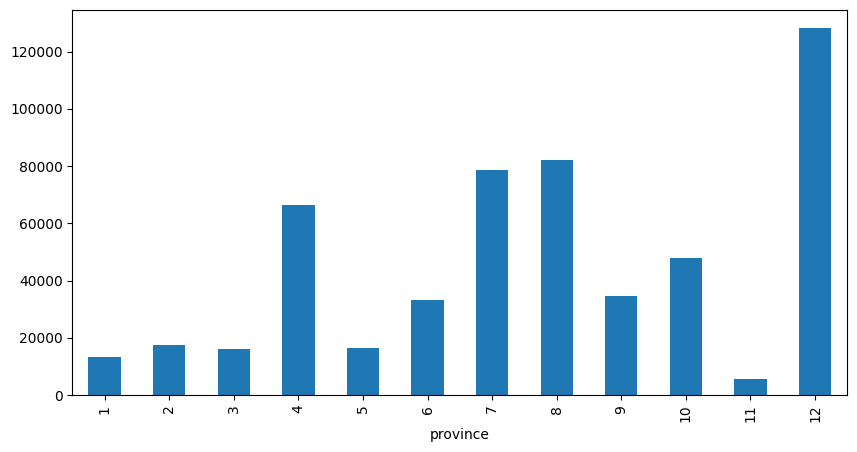

In [81]:
data["province"].value_counts().sort_index().plot(kind="bar", figsize=(10, 5))

In [82]:
municipality_to_province = data.groupby("municipality")["province"].nunique().sort_values(ascending=False)

print(municipality_to_province.head(20))
print("Broj municipality koji pripadaju vise od jedne province:",
      (municipality_to_province > 1).sum())

municipality
298    2
360    1
1      1
2      1
3      1
4      1
5      1
6      1
345    1
330    1
331    1
332    1
333    1
334    1
335    1
336    1
337    1
338    1
339    1
340    1
Name: province, dtype: int64
Broj municipality koji pripadaju vise od jedne province: 1


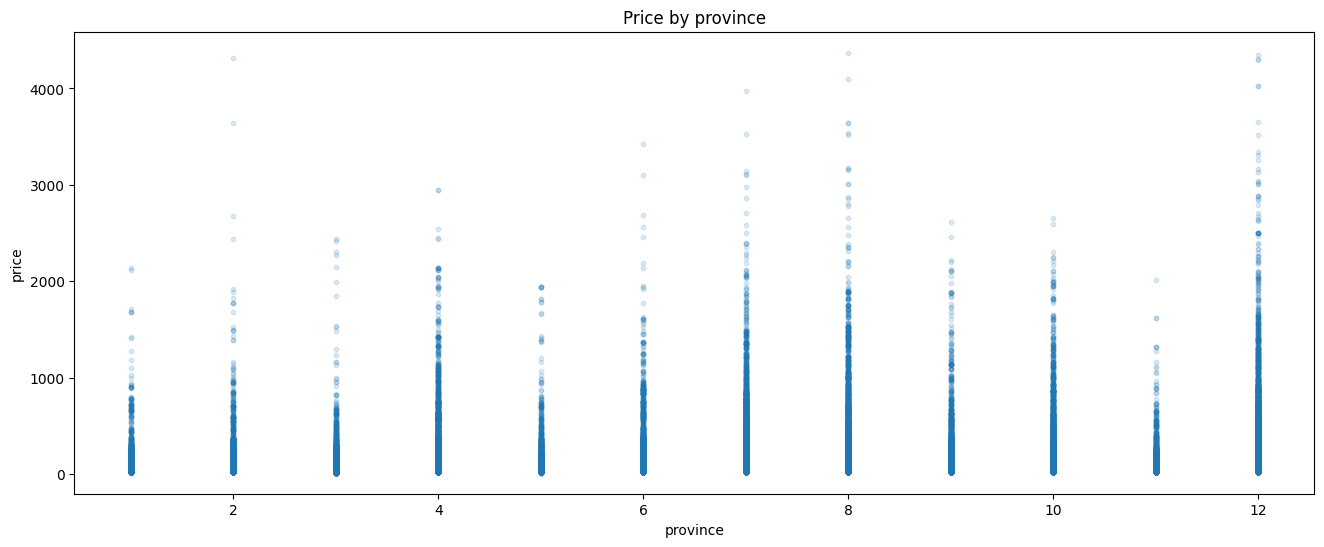

In [87]:

plt.figure(figsize=(16, 6))
plt.scatter(data["province"], data["Insurer_A_price"], alpha=0.15, s=10)
plt.xlabel("province")
plt.ylabel("price")
plt.title("Price by province")
plt.show()

Province 12 prosecna cena: 134.88
Ostale province prosecna cena: 114.58

                                              feature  province_12_mean  \
50               postal_code_attractions_within_20_km         17.544338   
33     postal_code_hospitals_incl_clinic_within_10_km          6.059581   
47         postal_code_department_stores_within_10_km         11.897288   
32     postal_code_hospitals_excl_clinic_within_10_km          3.427232   
38     postal_code_secondary_schools_vmbo_within_5_km         11.613435   
36          postal_code_secondary_schools_within_5_km         14.908317   
35            postal_code_primary_schools_within_3_km         16.560712   
49         postal_code_after_school_cares_within_3_km         23.454751   
48                   postal_code_daycares_within_3_km         34.542738   
29              postal_code_nearest_ice_rink_distance         10.284685   
40                  postal_code_groceries_within_3_km         89.906235   
45                   postal

In [95]:
# Proveri redundantne feature-e
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numeric_cols].corr()

# Pronađi parove sa korelacijom > 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Redundantni feature-i (korelacija > 0.95):")
for pair in high_corr_pairs[:10]:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.4f}")

Redundantni feature-i (korelacija > 0.95):
  vehicle_power - vehicle_net_max_power: 0.9977
  vehicle_net_weight - vehicle_gross_weight: 0.9816
  postal_code_owner_occupied_houses_ratio - postal_code_rental_houses_ratio: -0.9900
  postal_code_nearest_secondary_school_distance - postal_code_nearest_secondary_school_vmbo_distance: 0.9851
  postal_code_secondary_schools_within_5_km - postal_code_secondary_schools_havo_vwo_within_5_km: 0.9508
  postal_code_secondary_schools_within_5_km - postal_code_secondary_schools_vmbo_within_5_km: 0.9815
  postal_code_groceries_within_3_km - postal_code_cafes_within_3_km: 0.9539
  postal_code_groceries_within_3_km - postal_code_snackbars_within_3_km: 0.9580
  postal_code_cafes_within_3_km - postal_code_snackbars_within_3_km: 0.9641
  postal_code_museums_within_10_km - postal_code_performance_venues_within_10_km: 0.9617


EKSPERIMENT: SA REDUNDANTNIM FEATURE-IMA


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [97]:
target_col = 'Insurer_H_price'
if target_col not in data.columns:
    print(f"❌ Kolona {target_col} ne postoji!")
    print(f"Dostupne cene: {[col for col in data.columns if col.endswith('_price')]}")
else:
    print(f"Analiza za: {target_col}")
    print(f"Broj redova: {data[target_col].count()}")
    print(f"NaN vrednosti: {data[target_col].isna().sum()}")
    
    # Izdvoji sve numeričke kolone osim cena
    price_cols = [col for col in data.columns if col.endswith('_price')]
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    # Ukloni sve price kolone iz feature-a (uključujući i target)
    feature_cols = [col for col in numeric_cols if col not in price_cols]
    
    print(f"\nBroj numeričkih feature-a: {len(feature_cols)}")
    
    # Izračunaj korelacije
    correlations = {}
    for col in feature_cols:
        # Ukloni NaN za ovaj par
        valid_data = data[[col, target_col]].dropna()
        if len(valid_data) > 10:
            corr = valid_data[col].corr(valid_data[target_col])
            correlations[col] = corr
    
    # Pretvori u DataFrame i sortiraj
    corr_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'correlation'])
    corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)
    
    print("\n" + "="*80)
    print(f"TOP 20 KORELACIJA SA {target_col}")
    print("="*80)
    print(corr_df.head(20).to_string(index=False))

Analiza za: Insurer_H_price
Broj redova: 113403
NaN vrednosti: 427889

Broj numeričkih feature-a: 136


c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stdd


TOP 20 KORELACIJA SA Insurer_H_price
                                           feature  correlation
                              Insurer_C_deductible     0.364093
                              Insurer_B_deductible     0.338929
        postal_code_department_stores_within_10_km     0.310885
                              Insurer_J_deductible     0.310223
                              Insurer_A_deductible     0.303418
                  postal_code_museums_within_10_km     0.289743
                  postal_code_daycares_within_3_km     0.283584
    postal_code_hospitals_excl_clinic_within_10_km     0.282188
                  postal_code_cinemas_within_10_km     0.281537
        postal_code_after_school_cares_within_3_km     0.279259
       postal_code_performance_venues_within_10_km     0.277722
           postal_code_primary_schools_within_3_km     0.277459
    postal_code_hospitals_incl_clinic_within_10_km     0.275326
                                vehicle_net_weight     0.274651
  

c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [98]:
def remove_high_correlation_features(data, threshold=0.95, keep_targets=None, verbose=True):
    """
    Uklanja jedan feature iz svakog para sa korelacijom > threshold
    
    Parameters:
    -----------
    data : DataFrame
    threshold : float
        Prag korelacije (default 0.95)
    keep_targets : list
        Liste kolona koje MORAJU biti zadržane (npr. cene)
    verbose : bool
        Da li štampati detalje
    
    Returns:
    --------
    data_clean : DataFrame
        DataFrame bez redundantnih kolona
    removed_cols : list
        Lista izbačenih kolona
    """
    
    if keep_targets is None:
        keep_targets = []
    
    data_clean = data.copy()
    removed_cols = []
    
    # Izaberi samo numeričke kolone
    numeric_cols = data_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    # Ukloni target kolone iz razmatranja (ne smeju se izbaciti)
    cols_to_check = [col for col in numeric_cols if col not in keep_targets]
    
    if len(cols_to_check) < 2:
        print("Nema dovoljno numeričkih kolona za proveru")
        return data_clean, removed_cols
    
    if verbose:
        print("="*80)
        print(f"UKLANJANJE VISOKO KORELISANIH FEATURE-A (prag: {threshold})")
        print("="*80)
        print(f"Broj numeričkih kolona za proveru: {len(cols_to_check)}")
    
    # Izračunaj korelacionu matricu
    corr_matrix = data_clean[cols_to_check].corr().abs()
    
    # Gornji trougao matrice (bez dijagonale)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Pronađi kolone za izbacivanje
    to_drop = []
    
    for column in upper.columns:
        if column in to_drop:
            continue
        
        # Pronađi kolone sa korelacijom > threshold
        high_corr_cols = upper.index[upper[column] > threshold].tolist()
        
        for corr_col in high_corr_cols:
            if corr_col not in to_drop:
                corr_value = corr_matrix.loc[column, corr_col]
                to_drop.append(corr_col)
                removed_cols.append(corr_col)
                
                if verbose:
                    print(f"   ✗ IZBACUJEM: {corr_col}")
                    print(f"     (korelacija {corr_value:.4f} sa {column})")
    
    # Izbaci kolone
    if to_drop:
        data_clean = data_clean.drop(columns=to_drop, errors='ignore')
        
        if verbose:
            print("\n" + "="*80)
            print("STATISTIKA")
            print("="*80)
            print(f"Pre izbacivanja: {len(data.columns)} kolona")
            print(f"Posle izbacivanja: {len(data_clean.columns)} kolona")
            print(f"Izbačeno: {len(to_drop)} kolona")
    else:
        if verbose:
            print("\n✅ Nema kolona za izbacivanje (sve korelacije ispod praga)")
    
    return data_clean, removed_cols

In [99]:
data, removed = remove_high_correlation_features(
        data, 
        threshold=0.97, 
        keep_targets=price_cols,  # Cene se ne izbacuju
        verbose=True
    )

UKLANJANJE VISOKO KORELISANIH FEATURE-A (prag: 0.97)
Broj numeričkih kolona za proveru: 136
   ✗ IZBACUJEM: vehicle_net_weight
     (korelacija 0.9816 sa vehicle_gross_weight)
   ✗ IZBACUJEM: vehicle_power
     (korelacija 0.9977 sa vehicle_net_max_power)
   ✗ IZBACUJEM: postal_code_owner_occupied_houses_ratio
     (korelacija 0.9900 sa postal_code_rental_houses_ratio)
   ✗ IZBACUJEM: postal_code_nearest_secondary_school_distance
     (korelacija 0.9851 sa postal_code_nearest_secondary_school_vmbo_distance)
   ✗ IZBACUJEM: postal_code_secondary_schools_within_5_km
     (korelacija 0.9815 sa postal_code_secondary_schools_vmbo_within_5_km)

STATISTIKA
Pre izbacivanja: 156 kolona
Posle izbacivanja: 151 kolona
Izbačeno: 5 kolona


In [108]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,is_driver_owner,usage,second_driver_birthdate,second_driver_claim_free_years,vehicle_maker,vehicle_model,vehicle_fuel_type,vehicle_engine_size,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_number_of_wheels,vehicle_primary_color,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_first_registration_date,vehicle_country_first_registration_date,vehicle_last_registration_date,vehicle_years_since_country_first_registration,vehicle_inspection_report_date,vehicle_inspection_expiry_date,vehicle_inspection_number_of_deficiencies_found,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,vehicle_is_imported_within_last_12_months,vehicle_can_be_registered,vehicle_has_open_recall,vehicle_is_marked_for_export,vehicle_is_taxi,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_rental_houses_ratio,postal_code_houses_owned_by_rental_association_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermarkets_within_3_km,postal_code_groceries_within_3_km,postal_code_restaurants_within_3_km,postal_code_cafes_within_3_km,postal_code_snackbars_within_3_km,postal_cod

In [110]:
data['claim_free_years'].value_counts()

claim_free_years
0     159429
1      50057
2      41939
3      33230
5      32015
4      25181
6      19120
10     18819
7      15766
8      15119
15     11817
9      10211
20      9845
12      9723
11      8517
13      7328
14      6975
25      6542
18      6130
16      5427
17      5144
30      4483
19      3875
22      3240
-1      2767
23      2708
21      2652
24      2350
-2      2287
28      2138
26      2127
27      2106
35      1476
40      1416
29      1228
-3      1038
32       954
31       843
34       722
33       667
36       488
38       438
37       373
42       337
50       337
45       332
39       285
44       253
41       234
43       168
46        98
48        86
55        83
49        61
60        52
47        51
52        43
51        43
56        19
53        18
54        18
57        15
58        11
62        10
61         8
82         4
63         3
65         3
70         2
81         2
77         1
68         1
59         1
80         1
66         1
64      

OSNOVNA STATISTIKA ZA claim_free_years
Broj redova: 541292
NaN vrednosti: 0
Unique vrednosti: 76

Statistika:
count     541292
unique        76
top            0
freq      159429
Name: claim_free_years, dtype: object


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

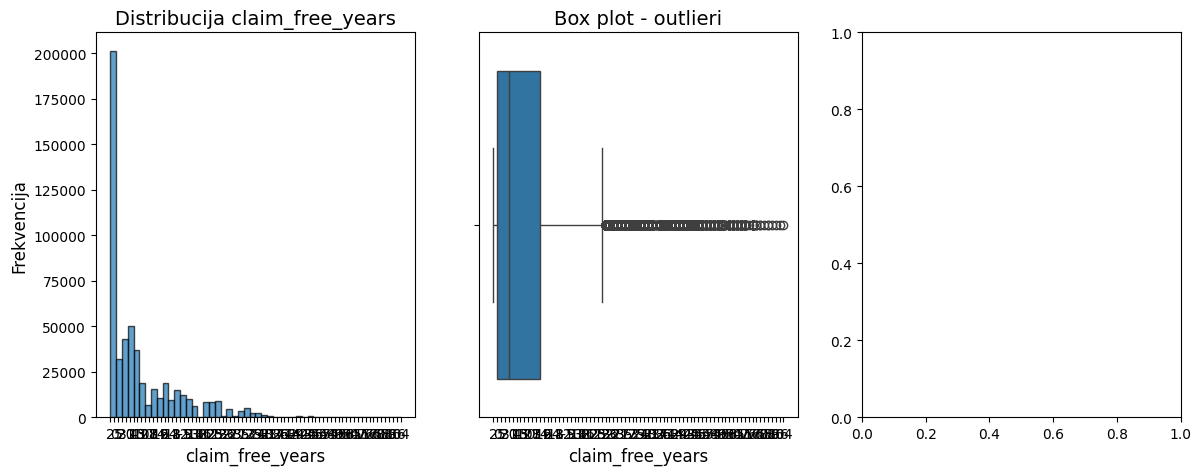

In [111]:

# Proveri osnovne statistike
print("="*80)
print("OSNOVNA STATISTIKA ZA claim_free_years")
print("="*80)

print(f"Broj redova: {len(data)}")
print(f"NaN vrednosti: {data['claim_free_years'].isna().sum()}")
print(f"Unique vrednosti: {data['claim_free_years'].nunique()}")
print(f"\nStatistika:")
print(data['claim_free_years'].describe())

# Histogram
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(data['claim_free_years'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('claim_free_years', fontsize=12)
plt.ylabel('Frekvencija', fontsize=12)
plt.title('Distribucija claim_free_years', fontsize=14)

# Box plot
plt.subplot(1, 3, 2)
sns.boxplot(x=data['claim_free_years'].dropna())
plt.xlabel('claim_free_years', fontsize=12)
plt.title('Box plot - outlieri', fontsize=14)

# Q-Q plot za proveru normalnosti
plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(data['claim_free_years'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q plot', fontsize=14)

plt.tight_layout()
plt.show()

In [112]:
data['claim_free_years'].isna().sum()   

np.int64(0)

In [114]:
def drop_all_null_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Brise kolone koje imaju samo null vrednosti.
    """
    return df.dropna(axis=1, how="all")


def drop_almost_constant_columns(df: pd.DataFrame, threshold: float = 0.99) -> pd.DataFrame:
    cols_to_drop = []

    for col in df.columns:
        non_null = df[col].dropna()

        if non_null.empty:
            continue

        most_common_ratio = non_null.value_counts(normalize=True, dropna=True).iloc[0]

        if most_common_ratio >= threshold:
            cols_to_drop.append(col)

    return df.drop(columns=cols_to_drop)


In [115]:
data = drop_all_null_columns(data)
data = drop_almost_constant_columns(data, threshold=0.99)

In [119]:
data['vehicle_year_of_last_odometer_report'].value_counts()

vehicle_year_of_last_odometer_report
2025.0    494339
2024.0     41158
2023.0      2963
2022.0       801
2021.0       183
2020.0        88
2018.0        51
2019.0        50
2016.0        38
2017.0        30
2015.0        26
2014.0        18
2009.0        12
2011.0         9
2013.0         7
2005.0         5
2006.0         5
2012.0         3
1992.0         3
2000.0         2
2008.0         2
2002.0         2
2001.0         2
2010.0         2
2004.0         1
1993.0         1
1994.0         1
Name: count, dtype: int64

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ciljne kolone
distance_col = 'postal_code_distance_to_border'
price_col = 'Insurer_G_price'

# Proveri da li kolone postoje
if distance_col not in data.columns:
    print(f"❌ Kolona {distance_col} ne postoji!")
    print(f"Dostupne postal kolone: {[col for col in data.columns if 'distance' in col.lower()][:10]}")
else:
    print(f"✅ Kolona {distance_col} postoji")
    
if price_col not in data.columns:
    print(f"❌ Kolona {price_col} ne postoji!")
    print(f"Dostupne cene: {[col for col in data.columns if col.endswith('_price')]}")
else:
    print(f"✅ Kolona {price_col} postoji")

# Ukloni NaN
valid_data = data[[distance_col, price_col]].dropna()
print(f"\nBroj validnih parova: {len(valid_data)}")

# Osnovna statistika
print("\n" + "="*80)
print("OSNOVNA STATISTIKA")
print("="*80)
print(f"\n{distance_col}:")
print(valid_data[distance_col].describe())
print(f"\n{price_col}:")
print(valid_data[price_col].describe())

✅ Kolona postal_code_distance_to_border postoji
✅ Kolona Insurer_G_price postoji

Broj validnih parova: 314219

OSNOVNA STATISTIKA

postal_code_distance_to_border:
count    314219.000000
mean         52.995863
std          35.252159
min           0.050235
25%          20.164223
50%          50.444318
75%          74.220336
max         193.070439
Name: postal_code_distance_to_border, dtype: float64

Insurer_G_price:
count    314219.000000
mean         84.512608
std          51.646317
min          12.480000
25%          49.260000
50%          70.350000
75%         103.750000
max         646.480000
Name: Insurer_G_price, dtype: float64


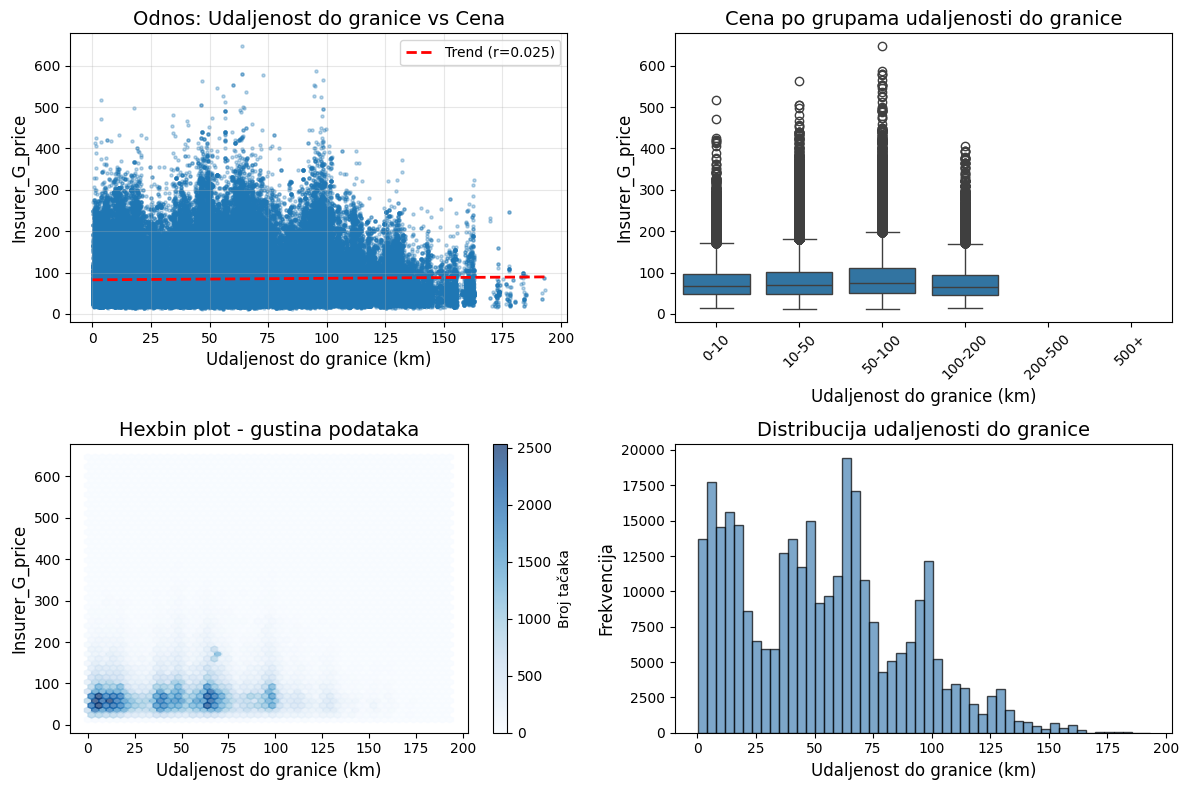

In [122]:
plt.figure(figsize=(12, 8))

# Scatter plot
plt.subplot(2, 2, 1)
plt.scatter(valid_data[distance_col], valid_data[price_col], alpha=0.3, s=5)
plt.xlabel('Udaljenost do granice (km)', fontsize=12)
plt.ylabel(f'{price_col}', fontsize=12)
plt.title('Odnos: Udaljenost do granice vs Cena', fontsize=14)

# Dodaj trend liniju
z = np.polyfit(valid_data[distance_col], valid_data[price_col], 1)
p = np.poly1d(z)
x_sorted = np.sort(valid_data[distance_col])
plt.plot(x_sorted, p(x_sorted), "r--", linewidth=2, label=f'Trend (r={valid_data[distance_col].corr(valid_data[price_col]):.3f})')
plt.legend()
plt.grid(alpha=0.3)

# Box plot po grupama udaljenosti
plt.subplot(2, 2, 2)
# Grupisanje udaljenosti
valid_data['distance_group'] = pd.cut(valid_data[distance_col], 
                                       bins=[0, 10, 50, 100, 200, 500, 1000],
                                       labels=['0-10', '10-50', '50-100', '100-200', '200-500', '500+'])
sns.boxplot(x='distance_group', y=price_col, data=valid_data)
plt.xlabel('Udaljenost do granice (km)', fontsize=12)
plt.ylabel(price_col, fontsize=12)
plt.title('Cena po grupama udaljenosti do granice', fontsize=14)
plt.xticks(rotation=45)

# Hexbin plot (bolji za veliki broj tačaka)
plt.subplot(2, 2, 3)
plt.hexbin(valid_data[distance_col], valid_data[price_col], gridsize=50, cmap='Blues', alpha=0.7)
plt.colorbar(label='Broj tačaka')
plt.xlabel('Udaljenost do granice (km)', fontsize=12)
plt.ylabel(price_col, fontsize=12)
plt.title('Hexbin plot - gustina podataka', fontsize=14)

# Histogrami
plt.subplot(2, 2, 4)
plt.hist(valid_data[distance_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Udaljenost do granice (km)', fontsize=12)
plt.ylabel('Frekvencija', fontsize=12)
plt.title('Distribucija udaljenosti do granice', fontsize=14)

plt.tight_layout()
plt.show()

In [128]:
# Ciljne kolone
distance_col = 'postal_code_distance_to_border'
price_col = 'Insurer_G_price'
province_col = 'province'

# Proveri da li kolone postoje
print("="*80)
print("PROVERA KOLONA")
print("="*80)
print(f"✅ {distance_col}: {'da' if distance_col in data.columns else 'ne'}")
print(f"✅ {price_col}: {'da' if price_col in data.columns else 'ne'}")
print(f"✅ {province_col}: {'da' if province_col in data.columns else 'ne'}")

# Ukloni NaN
valid_data = data[[distance_col, price_col, province_col]].dropna()
print(f"\nBroj validnih redova: {len(valid_data)}")

# Prikaz province
print(f"\nProvince vrednosti: {sorted(valid_data[province_col].unique())}")
print(f"Broj provincija: {valid_data[province_col].nunique()}")

PROVERA KOLONA
✅ postal_code_distance_to_border: da
✅ Insurer_G_price: da
✅ province: da

Broj validnih redova: 313414

Province vrednosti: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Broj provincija: 12


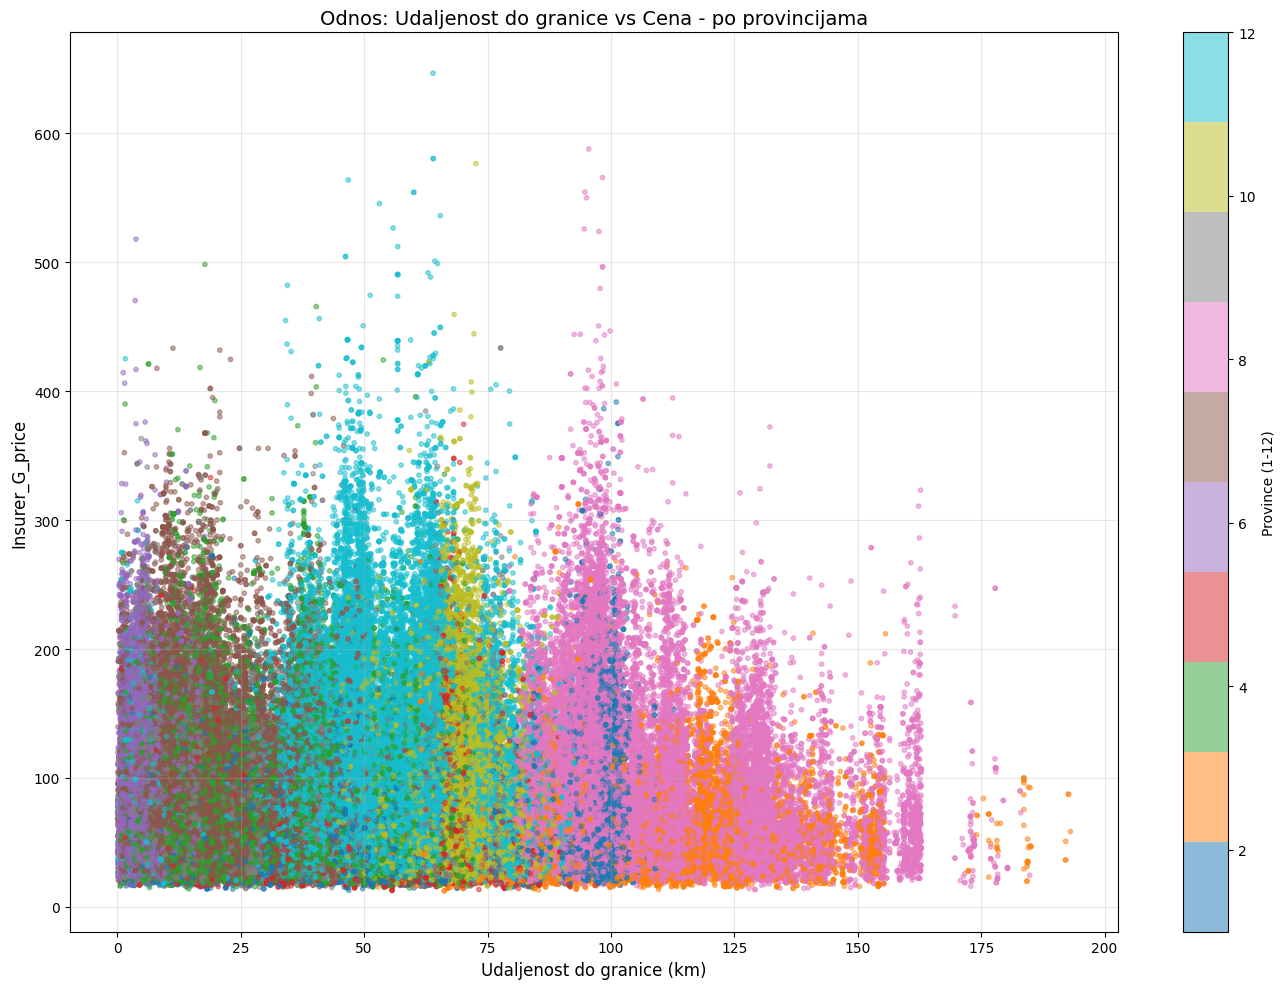

In [129]:
plt.figure(figsize=(14, 10))

# Scatter plot sa različitim bojama za province
scatter = plt.scatter(valid_data[distance_col], valid_data[price_col], 
                      c=valid_data[province_col], cmap='tab10', 
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Province (1-12)')
plt.xlabel('Udaljenost do granice (km)', fontsize=12)
plt.ylabel(price_col, fontsize=12)
plt.title(f'Odnos: Udaljenost do granice vs Cena - po provincijama', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Target kolona
target = 'Insurer_A_price'

# Proveri da li target postoji
if target not in data.columns:
    print(f"❌ Kolona {target} ne postoji!")
    print(f"Dostupne cene: {[col for col in data.columns if col.endswith('_price')]}")
else:
    print(f"✅ Target: {target}")
    print(f"Broj redova: {data[target].count()}")
    print(f"NaN vrednosti: {data[target].isna().sum()}")

# Izdvoji sve numeričke kolone (osim ostalih cena)
price_cols = [col for col in data.columns if col.endswith('_price')]
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Ukloni sve cene iz feature-a (ostavi samo target za kasnije)
feature_cols = [col for col in numeric_cols if col not in price_cols]

print(f"\nBroj numeričkih feature-a: {len(feature_cols)}")

✅ Target: Insurer_A_price
Broj redova: 527372
NaN vrednosti: 13920

Broj numeričkih feature-a: 110


In [132]:
# Izračunaj korelacije svih feature-a sa target-om
correlations = {}

for col in feature_cols:
    valid_data = data[[col, target]].dropna()
    if len(valid_data) > 100:  # Dovoljno podataka za pouzdanu korelaciju
        corr = valid_data[col].corr(valid_data[target])
        correlations[col] = corr

# Pretvori u DataFrame i sortiraj
corr_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'correlation'])
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)

print("\n" + "="*80)
print(f"TOP 20 KORELACIJA SA {target}")
print("="*80)
print(corr_df.head(20).to_string(index=False))

c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\zKi\Desktop\Hackathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())



TOP 20 KORELACIJA SA Insurer_A_price
                                       feature  correlation
                             vehicle_value_new     0.182635
                         vehicle_net_max_power     0.173265
                          vehicle_gross_weight     0.164966
                          Insurer_C_deductible     0.159228
                           vehicle_engine_size     0.156424
                   vehicle_number_of_cylinders     0.124288
                          Insurer_H_deductible     0.105445
    postal_code_department_stores_within_10_km     0.104322
                    vehicle_ownership_duration    -0.104027
                vehicle_net_max_power_electric     0.104022
                          Insurer_A_deductible     0.102936
postal_code_hospitals_excl_clinic_within_10_km     0.094057
       postal_code_primary_schools_within_3_km     0.093894
          vehicle_nominal_continuous_max_power     0.093581
postal_code_hospitals_incl_clinic_within_10_km     0.092939
po

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ciljne kolone
x_col = 'vehicle_value_new'
y_col = 'Insurer_A_price'

# Proveri da li kolone postoje
print("="*80)
print("PROVERA KOLONA")
print("="*80)
print(f"✅ {x_col}: {'da' if x_col in data.columns else 'ne'}")
print(f"✅ {y_col}: {'da' if y_col in data.columns else 'ne'}")

if x_col not in data.columns or y_col not in data.columns:
    print("\n❌ Nedostaju kolone!")
else:
    # Ukloni NaN
    valid_data = data[[x_col, y_col]].dropna()
    print(f"\nBroj validnih parova: {len(valid_data)}")
    
    # Osnovna statistika
    print("\n" + "="*80)
    print("OSNOVNA STATISTIKA")
    print("="*80)
    print(f"\n{x_col}:")
    print(valid_data[x_col].describe())
    print(f"\n{y_col}:")
    print(valid_data[y_col].describe())
    
    # Korelacija
    corr = valid_data[x_col].corr(valid_data[y_col])
    print(f"\nKorelacija: {corr:.4f}")

PROVERA KOLONA
✅ vehicle_value_new: da
✅ Insurer_A_price: da

Broj validnih parova: 524643

OSNOVNA STATISTIKA

vehicle_value_new:
count    5.246430e+05
mean     3.505800e+04
std      2.280838e+04
min      5.000000e+02
25%      1.890900e+04
50%      2.941100e+04
75%      4.498900e+04
max      1.579134e+06
Name: vehicle_value_new, dtype: float64

Insurer_A_price:
count    524643.000000
mean         96.837232
std         115.583112
min          12.330800
25%          44.817500
50%          67.704200
75%         111.618750
max        4370.410000
Name: Insurer_A_price, dtype: float64

Korelacija: 0.1826


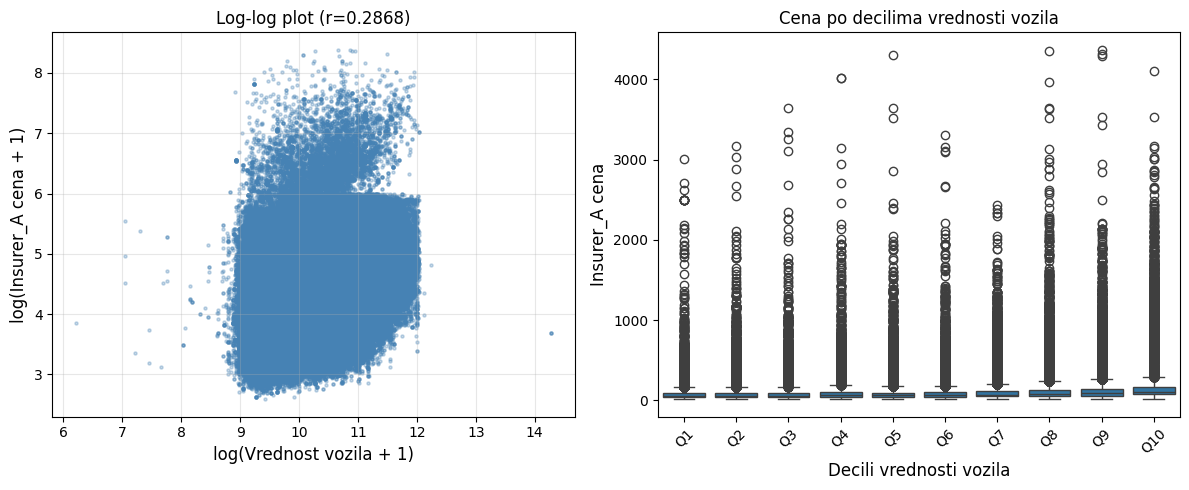

In [136]:
plt.figure(figsize=(12, 5))

# Log-log plot
plt.subplot(1, 2, 1)
plt.scatter(np.log1p(valid_data[x_col]), np.log1p(valid_data[y_col]), alpha=0.3, s=5, color='steelblue')
plt.xlabel('log(Vrednost vozila + 1)', fontsize=12)
plt.ylabel('log(Insurer_A cena + 1)', fontsize=12)
plt.title(f'Log-log plot (r={np.log1p(valid_data[x_col]).corr(np.log1p(valid_data[y_col])):.4f})', fontsize=12)
plt.grid(alpha=0.3)

# Box plot po grupama vrednosti
plt.subplot(1, 2, 2)
# Grupisanje vrednosti vozila
valid_data['value_group'] = pd.qcut(valid_data[x_col], q=10, labels=[f'Q{i+1}' for i in range(10)])
sns.boxplot(x='value_group', y=y_col, data=valid_data)
plt.xlabel('Decili vrednosti vozila', fontsize=12)
plt.ylabel('Insurer_A cena', fontsize=12)
plt.title('Cena po decilima vrednosti vozila', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [145]:
print(data.columns.tolist())

['quote_id', 'vehicle_ownership_duration', 'vehicle_number_plate', 'coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'vehicle_model', 'vehicle_engine_size', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_years_since_country_first_registration', 'vehicle_year_of_last_odometer_report', 'vehicle_odometer_verdict_code', 'vehicle_planned_annual_mileage', 'vehicle_is_imported', 'postal_code', 'province', 'municipality', 'municipality_crimes_per_1000', 'postal_code_latitude', 'postal_code_longitude', 'postal_code_distance_to_border', 'postal_code_urban_category', 'postal_code_population', 'postal_code_households', 'postal_code_houses', 'postal_code_average_household_size', 'p

In [147]:
feature_groups = {
    
    # 1. COVERAGE & POLICY (Polisa i uslovi)
    'Coverage & Policy': [
        'coverage',                    # Tip pokrića (mtpl, limited_casco, casco)
        'claim_free_years',            # Godine bez štete (bonus/malus sistem)
        'payment_frequency'            # Učestalost plaćanja
    ],
    
    # 2. DRIVER PROFILE (Profil vozača)
    'Driver Profile': [
        'contractor_birthdate',        # Datum rođenja ugovarača
        'vehicle_planned_annual_mileage', # Planirana godišnja kilometraža
        # Napomena: is_driver_owner, usage, second_driver_birthdate, 
        # second_driver_claim_free_years nisu u tvojoj listi ali bi trebalo da budu
    ],
    
    # 3. VEHICLE - PHYSICAL (Fizičke karakteristike vozila)
    'Vehicle - Physical': [
        'vehicle_model',               # Model vozila
        'vehicle_engine_size',         # Zapremina motora
        'vehicle_gross_weight',        # Bruto težina
        'vehicle_length',              # Dužina
        'vehicle_width',               # Širina
        'vehicle_height',              # Visina
        'vehicle_number_of_cylinders', # Broj cilindara
        'vehicle_number_of_doors',     # Broj vrata
        'vehicle_number_of_seats',     # Broj sedišta
        'vehicle_value_new',           # Vrednost novog vozila
        'vehicle_net_max_power',       # Maksimalna snaga
        'vehicle_net_max_power_electric', # Snaga elektromotora
        'vehicle_nominal_continuous_max_power', # Nominalna snaga
        'vehicle_power_to_net_weight_ratio' # Odnos snage i težine
    ],
    
    # 4. VEHICLE - ADMINISTRATIVE (Administrativne karakteristike vozila)
    'Vehicle - Administrative': [
        'vehicle_ownership_duration',  # Trajanje vlasništva
        'vehicle_age',                 # Starost vozila
        'vehicle_years_since_country_first_registration', # Godine od registracije u zemlji
        'vehicle_year_of_last_odometer_report', # Godina poslednjeg očitavanja
        'vehicle_odometer_verdict_code', # Verdict kod (5.0, 0.0...)
        'vehicle_is_imported',         # Da li je uvezeno
        # Napomena: vehicle_number_plate je ID, ne koristi se za model
    ],
    
    # 5. LOCATION - BASIC & GEOGRAPHY (Osnovna lokacija i geografija)
    'Location - Basic & Geography': [
        'postal_code',                 # Poštanski broj (2-digit)
        'province',                    # Provincija (1-12)
        'municipality',                # Opština
        'postal_code_latitude',        # Geografska širina
        'postal_code_longitude',       # Geografska dužina
        'postal_code_distance_to_border', # Udaljenost do granice
        'postal_code_urban_category'   # Urbana kategorija (1-5)
    ],
    
    # 6. LOCATION - SOCIOECONOMICS & AMENITIES (Socioekonomija i sadržaji)
    'Location - Socioeconomics & Amenities': [
        'municipality_crimes_per_1000', # Krivična dela na 1000 stanovnika
        'postal_code_population',       # Populacija
        'postal_code_households',       # Broj domaćinstava
        'postal_code_houses',           # Broj kuća
        'postal_code_average_household_size', # Prosečna veličina domaćinstva
        'postal_code_0_to_15_years_inhabitants_ratio', # Udeo 0-15 god.
        'postal_code_25_to_45_years_inhabitants_ratio', # Udeo 25-45 god.
        'postal_code_45_to_65_years_inhabitants_ratio', # Udeo 45-65 god.
        'postal_code_65_years_and_older_inhabitants_ratio', # Udeo 65+ god.
        'postal_code_single_person_households_ratio', # Udeo samaca
        'postal_code_multi_person_households_without_children_ratio', # Domaćinstva bez dece
        'postal_code_two_parent_households_ratio', # Domaćinstva sa oba roditelja
        'postal_code_social_benefit_recipients_ratio', # Udeo korisnika socijalne pomoći
        'postal_code_address_density', # Gustina adresa
        'postal_code_average_property_value', # Prosečna vrednost nekretnine
        'postal_code_rental_houses_ratio', # Udeo iznajmljenih kuća
        'postal_code_multi_family_houses_ratio', # Udeo višeportodičnih kuća
        'postal_code_houses_built_before_1945_ratio', # Kuće pre 1945
        'postal_code_houses_built_45_to_65_ratio', # Kuće 1945-1965
        'postal_code_houses_built_65_to_75_ratio', # Kuće 1965-1975
        'postal_code_houses_built_75_to_85_ratio', # Kuće 1975-1985
        'postal_code_houses_built_85_to_95_ratio', # Kuće 1985-1995
        'postal_code_houses_built_95_to_05_ratio', # Kuće 1995-2005
        'postal_code_houses_built_05_to_15_ratio', # Kuće 2005-2015
        'postal_code_nearest_train_station_distance', # Udaljenost do železnice
        'postal_code_nearest_train_transfer_station_distance',
        'postal_code_nearest_motorway_ramp_distance', # Udaljenost do autoputa
        'postal_code_nearest_hospital_excl_clinic_distance', # Udaljenost do bolnice
        'postal_code_nearest_hospital_incl_clinic_distance',
        'postal_code_nearest_general_practitioner_distance', # Udaljenost do lekara
        'postal_code_nearest_gp_post_service_distance',
        'postal_code_nearest_pharmacy_distance', # Udaljenost do apoteke
        'postal_code_nearest_primary_school_distance', # Udaljenost do škole
        'postal_code_nearest_secondary_school_havo_vwo_distance',
        'postal_code_nearest_secondary_school_vmbo_distance',
        'postal_code_nearest_supermarket_distance', # Udaljenost do supermarketa
        'postal_code_nearest_groceries_distance',
        'postal_code_nearest_restaurant_distance',
        'postal_code_nearest_cafe_distance',
        'postal_code_nearest_snackbar_distance',
        'postal_code_nearest_hotel_distance',
        'postal_code_nearest_library_distance',
        'postal_code_nearest_museum_distance',
        'postal_code_nearest_cinema_distance',
        'postal_code_nearest_department_store_distance',
        'postal_code_nearest_fire_station_distance',
        'postal_code_nearest_daycare_distance',
        'postal_code_nearest_after_school_care_distance',
        'postal_code_nearest_attraction_distance',
        'postal_code_nearest_performance_venue_distance',
        'postal_code_nearest_music_venue_distance',
        'postal_code_nearest_swimming_pool_distance',
        'postal_code_nearest_ice_rink_distance',
        'postal_code_nearest_sauna_distance',
        'postal_code_nearest_tanning_salon_distance',
        'postal_code_hospitals_excl_clinic_within_10_km', # Broj bolnica u krugu
        'postal_code_hospitals_incl_clinic_within_10_km',
        'postal_code_general_practitioners_within_3_km', # Broj lekara u krugu
        'postal_code_primary_schools_within_3_km', # Broj škola u krugu
        'postal_code_secondary_schools_havo_vwo_within_5_km',
        'postal_code_secondary_schools_vmbo_within_5_km',
        'postal_code_supermarkets_within_3_km', # Broj supermarketa u krugu
        'postal_code_groceries_within_3_km',
        'postal_code_restaurants_within_3_km',
        'postal_code_cafes_within_3_km',
        'postal_code_snackbars_within_3_km',
        'postal_code_hotels_within_10_km',
        'postal_code_museums_within_10_km',
        'postal_code_cinemas_within_10_km',
        'postal_code_department_stores_within_10_km',
        'postal_code_daycares_within_3_km',
        'postal_code_after_school_cares_within_3_km',
        'postal_code_attractions_within_20_km',
        'postal_code_performance_venues_within_10_km'
    ]
}

In [148]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,vehicle_model,vehicle_engine_size,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_years_since_country_first_registration,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_rental_houses_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermarkets_within_3_km,postal_code_groceries_within_3_km,postal_code_restaurants_within_3_km,postal_code_cafes_within_3_km,postal_code_snackbars_within_3_km,postal_code_hotels_within_10_km,postal_code_museums_within_10_km,postal_code_cinemas_within_10_km,postal_code_department_stores_within_10_km,postal_code_daycares_within_3_km,postal_code_after_school_cares_within_3_km,postal_code_attractions_within_20_km,postal_code_performance_venues_within_10_km,Insurer_A_deductible,Insurer_B_deductible,Insurer_C_deductible,Insurer_E_deductible,Insurer_G_deductible,Insurer_H_deductible,Insurer_J_deductible,Insurer_K_deductible,Insurer_A_price,Insurer_B_price,Insurer_C_price,Insurer_D_price,Insurer_E_price,Insurer_F_price,Insurer

In [172]:
urban_feat = 'urban_amenities_score'  # ili 'urban_amenities_score', 'log_urban_score'

# Proveri da li postoji
if urban_feat not in data.columns:
    print(f"❌ {urban_feat} ne postoji!")
    print(f"Dostupne urban verzije: {[col for col in data.columns if 'urban' in col.lower()]}")
else:
    print(f"✅ Koristim: {urban_feat}")
    print(f"Broj redova: {data[urban_feat].count()}")
    print(f"NaN vrednosti: {data[urban_feat].isna().sum()}")

# Cene
price_cols = [col for col in data.columns if col.endswith('_price')]
insurers = [col.replace('_price', '') for col in price_cols]

print(f"\nBroj osiguravača: {len(insurers)}")

# Izračunaj korelacije
correlations = {}

for price_col in price_cols:
    insurer = price_col.replace('_price', '')
    valid = data[[urban_feat, price_col]].dropna()
    
    if len(valid) > 100:
        corr = valid[urban_feat].corr(valid[price_col])
        correlations[insurer] = corr
    else:
        correlations[insurer] = np.nan

# Pretvori u DataFrame i sortiraj
corr_df = pd.DataFrame(list(correlations.items()), columns=['insurer', 'correlation'])
corr_df = corr_df.sort_values('correlation', ascending=False)

print("\n" + "="*80)
print(f"KORELACIJE SA {urban_feat}")
print("="*80)
print(corr_df.round(4).to_string(index=False))

✅ Koristim: urban_amenities_score
Broj redova: 351059
NaN vrednosti: 190233

Broj osiguravača: 11

KORELACIJE SA urban_amenities_score
  insurer  correlation
Insurer_H       0.3065
Insurer_I       0.2913
Insurer_C       0.2650
Insurer_G       0.2363
Insurer_D       0.2173
Insurer_F       0.1930
Insurer_E       0.1909
Insurer_K       0.1844
Insurer_J       0.1813
Insurer_B       0.1767
Insurer_A       0.1011


In [173]:


def create_urban_risk_score(data):
    """
    Kreira risk score koji kombinuje pozitivne i negativne feature-e
    """
    
    positive_features = [
        'postal_code_department_stores_within_10_km',
        'postal_code_primary_schools_within_3_km',
        'postal_code_supermarkets_within_3_km',
        'postal_code_secondary_schools_vmbo_within_5_km',
        'postal_code_daycares_within_3_km',
        'postal_code_secondary_schools_within_5_km',
        'postal_code_after_school_cares_within_3_km',
        'postal_code_hospitals_incl_clinic_within_10_km',
        'postal_code_hospitals_excl_clinic_within_10_km',
        'postal_code_general_practitioners_within_3_km',
        'postal_code_cinemass_within_10_km',
        'postal_code_museums_within_10_km',
        'postal_code_groceries_within_3_km',
        'postal_code_performance_venues_within_10_km',
        'postal_code_snackbars_within_3_km',
        'postal_code_attractions_within_20_km',
        'postal_code_cafes_within_3_km'
    ]

    
    negative_features = [
        'postal_code_urban_category'
    ]
    
    data['urban_amenities_score'] = 0
    for feat in positive_features:
        if feat in data.columns:
            norm = (data[feat] - data[feat].min()) / (data[feat].max() - data[feat].min())
            data['urban_amenities_score'] += norm
    
    for feat in negative_features:
        if feat in data.columns:
            norm = 1 - (data[feat] - data[feat].min()) / (data[feat].max() - data[feat].min())
            data['urban_amenities_score'] += norm
    
    data['urban_amenities_score'] = data['urban_amenities_score'] / (len(positive_features) + len(negative_features))
    
    print("✅ Kreiran: urban_amenities_score")
    return data

data = create_urban_risk_score(data)

✅ Kreiran: urban_amenities_score


In [174]:
urban_feat = 'urban_amenities_score'  # ili 'urban_amenities_score', 'log_urban_score'

# Proveri da li postoji
if urban_feat not in data.columns:
    print(f"❌ {urban_feat} ne postoji!")
    print(f"Dostupne urban verzije: {[col for col in data.columns if 'urban' in col.lower()]}")
else:
    print(f"✅ Koristim: {urban_feat}")
    print(f"Broj redova: {data[urban_feat].count()}")
    print(f"NaN vrednosti: {data[urban_feat].isna().sum()}")

# Cene
price_cols = [col for col in data.columns if col.endswith('_price')]
insurers = [col.replace('_price', '') for col in price_cols]

print(f"\nBroj osiguravača: {len(insurers)}")

# Izračunaj korelacije
correlations = {}

for price_col in price_cols:
    insurer = price_col.replace('_price', '')
    valid = data[[urban_feat, price_col]].dropna()
    
    if len(valid) > 100:
        corr = valid[urban_feat].corr(valid[price_col])
        correlations[insurer] = corr
    else:
        correlations[insurer] = np.nan

# Pretvori u DataFrame i sortiraj
corr_df = pd.DataFrame(list(correlations.items()), columns=['insurer', 'correlation'])
corr_df = corr_df.sort_values('correlation', ascending=False)

print("\n" + "="*80)
print(f"KORELACIJE SA {urban_feat}")
print("="*80)
print(corr_df.round(4).to_string(index=False))

✅ Koristim: urban_amenities_score
Broj redova: 351059
NaN vrednosti: 190233

Broj osiguravača: 11

KORELACIJE SA urban_amenities_score
  insurer  correlation
Insurer_H       0.3065
Insurer_I       0.2913
Insurer_C       0.2650
Insurer_G       0.2363
Insurer_D       0.2173
Insurer_F       0.1930
Insurer_E       0.1909
Insurer_K       0.1844
Insurer_J       0.1813
Insurer_B       0.1767
Insurer_A       0.1011


In [175]:
data['coverage'].value_counts()

coverage
limited_casco    238176
casco            163742
mtpl             139374
Name: count, dtype: int64

In [179]:
data[['coverage','vehicle_value_new', 'Insurer_A_price']]

,coverage,vehicle_value_new,Insurer_A_price
0,mtpl,47410.0,119.7600
1,limited_casco,45105.0,233.7925
2,mtpl,15900.0,54.0125
3,limited_casco,45105.0,160.8592
4,limited_casco,16041.0,121.5292
...,...,...,...
541287,casco,67762.0,58.8942
541288,limited_casco,28634.0,67.5092
541289,mtpl,14307.0,69.5308
541290,limited_casco,23202.0,29.2867


In [180]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,vehicle_model,vehicle_engine_size,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_years_since_country_first_registration,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_rental_houses_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermarkets_within_3_km,postal_code_groceries_within_3_km,postal_code_restaurants_within_3_km,postal_code_cafes_within_3_km,postal_code_snackbars_within_3_km,postal_code_hotels_within_10_km,postal_code_museums_within_10_km,postal_code_cinemas_within_10_km,postal_code_department_stores_within_10_km,postal_code_daycares_within_3_km,postal_code_after_school_cares_within_3_km,postal_code_attractions_within_20_km,postal_code_performance_venues_within_10_km,Insurer_A_deductible,Insurer_B_deductible,Insurer_C_deductible,Insurer_E_deductible,Insurer_G_deductible,Insurer_H_deductible,Insurer_J_deductible,Insurer_K_deductible,Insurer_A_price,Insurer_B_price,Insurer_C_price,Insurer_D_price,Insurer_E_price,Insurer_F_price,Insurer

In [181]:
data["driver_age"] = (
    2026 - pd.to_datetime(data["contractor_birthdate"], dayfirst=True, errors="coerce").dt.year
).astype("Int64")

In [182]:
data["driver_age"]

0         21
1         24
2         26
3         24
4         21
          ..
541287    59
541288    44
541289    24
541290    32
541291    59
Name: driver_age, Length: 541292, dtype: Int64

In [183]:
data

,quote_id,vehicle_ownership_duration,vehicle_number_plate,coverage,claim_free_years,payment_frequency,contractor_birthdate,vehicle_model,vehicle_engine_size,vehicle_gross_weight,vehicle_length,vehicle_width,vehicle_height,vehicle_number_of_cylinders,vehicle_number_of_doors,vehicle_number_of_seats,vehicle_value_new,vehicle_net_max_power,vehicle_net_max_power_electric,vehicle_nominal_continuous_max_power,vehicle_power_to_net_weight_ratio,vehicle_age,vehicle_years_since_country_first_registration,vehicle_year_of_last_odometer_report,vehicle_odometer_verdict_code,vehicle_planned_annual_mileage,vehicle_is_imported,postal_code,province,municipality,municipality_crimes_per_1000,postal_code_latitude,postal_code_longitude,postal_code_distance_to_border,postal_code_urban_category,postal_code_population,postal_code_households,postal_code_houses,postal_code_average_household_size,postal_code_0_to_15_years_inhabitants_ratio,postal_code_25_to_45_years_inhabitants_ratio,postal_code_45_to_65_years_inhabitants_ratio,postal_code_65_years_and_older_inhabitants_ratio,postal_code_single_person_households_ratio,postal_code_multi_person_households_without_children_ratio,postal_code_two_parent_households_ratio,postal_code_social_benefit_recipients_ratio,postal_code_address_density,postal_code_average_property_value,postal_code_rental_houses_ratio,postal_code_multi_family_houses_ratio,postal_code_houses_built_before_1945_ratio,postal_code_houses_built_45_to_65_ratio,postal_code_houses_built_65_to_75_ratio,postal_code_houses_built_75_to_85_ratio,postal_code_houses_built_85_to_95_ratio,postal_code_houses_built_95_to_05_ratio,postal_code_houses_built_05_to_15_ratio,postal_code_nearest_train_station_distance,postal_code_nearest_train_transfer_station_distance,postal_code_nearest_motorway_ramp_distance,postal_code_nearest_hospital_excl_clinic_distance,postal_code_nearest_hospital_incl_clinic_distance,postal_code_nearest_general_practitioner_distance,postal_code_nearest_gp_post_service_distance,postal_code_nearest_pharmacy_distance,postal_code_nearest_primary_school_distance,postal_code_nearest_secondary_school_havo_vwo_distance,postal_code_nearest_secondary_school_vmbo_distance,postal_code_nearest_supermarket_distance,postal_code_nearest_groceries_distance,postal_code_nearest_restaurant_distance,postal_code_nearest_cafe_distance,postal_code_nearest_snackbar_distance,postal_code_nearest_hotel_distance,postal_code_nearest_library_distance,postal_code_nearest_museum_distance,postal_code_nearest_cinema_distance,postal_code_nearest_department_store_distance,postal_code_nearest_fire_station_distance,postal_code_nearest_daycare_distance,postal_code_nearest_after_school_care_distance,postal_code_nearest_attraction_distance,postal_code_nearest_performance_venue_distance,postal_code_nearest_music_venue_distance,postal_code_nearest_swimming_pool_distance,postal_code_nearest_ice_rink_distance,postal_code_nearest_sauna_distance,postal_code_nearest_tanning_salon_distance,postal_code_hospitals_excl_clinic_within_10_km,postal_code_hospitals_incl_clinic_within_10_km,postal_code_general_practitioners_within_3_km,postal_code_primary_schools_within_3_km,postal_code_secondary_schools_havo_vwo_within_5_km,postal_code_secondary_schools_vmbo_within_5_km,postal_code_supermarkets_within_3_km,postal_code_groceries_within_3_km,postal_code_restaurants_within_3_km,postal_code_cafes_within_3_km,postal_code_snackbars_within_3_km,postal_code_hotels_within_10_km,postal_code_museums_within_10_km,postal_code_cinemas_within_10_km,postal_code_department_stores_within_10_km,postal_code_daycares_within_3_km,postal_code_after_school_cares_within_3_km,postal_code_attractions_within_20_km,postal_code_performance_venues_within_10_km,Insurer_A_deductible,Insurer_B_deductible,Insurer_C_deductible,Insurer_E_deductible,Insurer_G_deductible,Insurer_H_deductible,Insurer_J_deductible,Insurer_K_deductible,Insurer_A_price,Insurer_B_price,Insurer_C_price,Insurer_D_price,Insurer_E_price,Insurer_F_price,Insurer

In [187]:
data["driver_age_band"] = pd.cut(
    data["driver_age"],
    bins=[17, 24, 30, 40, 50, 60, 70, 80, 90, 120],
    labels=["18-24", "25-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90", "90+"]
)

In [191]:
age_band_price = (
    data.groupby("driver_age_band", observed=False)["Insurer_A_price"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

print(age_band_price)

  driver_age_band   count        mean    median
0           18-24  115567  160.426368  143.2083
1           25-30  104152   88.119883   69.6242
2           31-40  122422   75.599591   55.3671
3           41-50   71407   76.629826   53.3717
4           51-60   56710   74.199992   49.8446
5           61-70   35641   73.575792   47.0883
6           71-80   16362   80.197606   51.6604
7           81-90    4329   96.694865   65.5425
8             90+     782  118.230721   83.9400


In [193]:
rows = []

for cov, g in data.groupby("coverage"):
    sub = g[["driver_age_band", "Insurer_A_price"]].dropna().copy()
    sub["age_band_code"] = sub["driver_age_band"].cat.codes
    corr = sub[["age_band_code", "Insurer_A_price"]].corr().iloc[0, 1]

    rows.append({
        "coverage": cov,
        "n_rows": len(sub),
        "age_band_price_corr": corr
    })

corr_df = pd.DataFrame(rows)
print(corr_df)

        coverage  n_rows  age_band_price_corr
0          casco  156664            -0.140055
1  limited_casco  231334            -0.340430
2           mtpl  139374            -0.297516


In [195]:
data['Insurer_E_price'].isna().sum()    

np.int64(138736)

In [203]:
def add_vehicle_score_selected_insurers(df: pd.DataFrame, selected_prices=None) -> pd.DataFrame:
    df = df.copy()

    vehicle_features = [
        "vehicle_ownership_duration",
        "vehicle_engine_size",
        "vehicle_power",
        "vehicle_net_weight",
        "vehicle_gross_weight",
        "vehicle_length",
        "vehicle_width",
        "vehicle_height",
        "vehicle_number_of_cylinders",
        "vehicle_number_of_doors",
        "vehicle_number_of_seats",
        "vehicle_value_new",
        "vehicle_net_max_power",
        "vehicle_net_max_power_electric",
        "vehicle_nominal_continuous_max_power",
        "vehicle_power_to_net_weight_ratio",
        "vehicle_age",
        "vehicle_years_since_country_first_registration",
        "vehicle_odometer_verdict_code",
        "vehicle_planned_annual_mileage",
    ]

    if selected_prices is None:
        selected_prices = [
            "Insurer_C_price",
            "Insurer_H_price",
            "Insurer_G_price",
            "Insurer_J_price",
        ]

    selected_prices = [c for c in selected_prices if c in df.columns]
    existing_features = [c for c in vehicle_features if c in df.columns]

    corr_matrix = df[existing_features + selected_prices].corr(numeric_only=True).loc[existing_features, selected_prices]
    feature_weights = corr_matrix.mean(axis=1)

    z = pd.DataFrame(index=df.index)
    for col in existing_features:
        s = pd.to_numeric(df[col], errors="coerce")
        std = s.std()
        if pd.notna(std) and std != 0:
            z[col] = (s - s.mean()) / std
        else:
            z[col] = 0.0

    raw_score = pd.Series(0.0, index=df.index)
    for col in existing_features:
        raw_score = raw_score + z[col].fillna(0) * feature_weights[col]

    min_val = raw_score.min()
    max_val = raw_score.max()

    if pd.notna(max_val) and pd.notna(min_val) and max_val != min_val:
        df["vehicle_score"] = (raw_score - min_val) / (max_val - min_val)
    else:
        df["vehicle_score"] = 0.5

    weight_table = (
        feature_weights
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("weight")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    return df

In [204]:
data = add_vehicle_score_selected_insurers(data)

In [205]:
data['vehicle_score']

0         0.224988
1         0.267773
2         0.150888
3         0.267773
4         0.169273
            ...   
541287    0.295883
541288    0.221671
541289    0.160165
541290    0.229134
541291    0.305090
Name: vehicle_score, Length: 541292, dtype: float64

In [206]:
price_cols = [c for c in data.columns if c.startswith("Insurer_") and c.endswith("_price")]
corrs = data[["vehicle_score"] + price_cols].corr(numeric_only=True).loc["vehicle_score", price_cols].sort_values(ascending=False)
print(corrs)

Insurer_C_price    0.374862
Insurer_J_price    0.332709
Insurer_H_price    0.295147
Insurer_G_price    0.238325
Insurer_A_price    0.181915
Insurer_B_price    0.181375
Insurer_F_price    0.177228
Insurer_D_price    0.170864
Insurer_E_price    0.136936
Insurer_K_price    0.091061
Insurer_I_price    0.038073
Name: vehicle_score, dtype: float64


In [207]:
data['postal_code_urban_category'].value_counts()

postal_code_urban_category
2.0    145192
1.0    142449
3.0     95571
4.0     84800
5.0     72747
Name: count, dtype: int64


ANALIZA PO COVERAGE TIPU

Insurer_E:
                count    mean  median    std
coverage                                    
casco          103140  129.14  106.75  80.79
limited_casco  175434  102.01   75.85  88.25
mtpl           123982  123.97   98.23  91.18


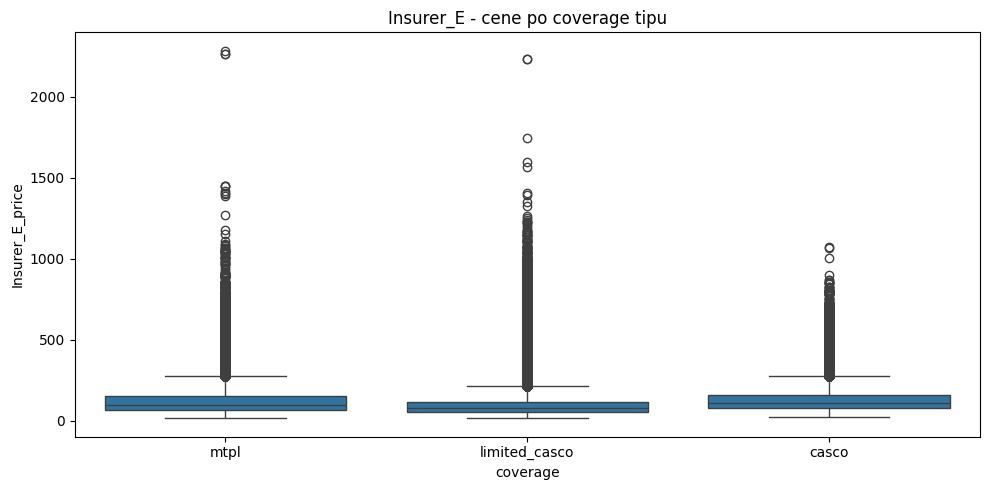


Insurer_I:
                count    mean  median    std
coverage                                    
casco           86186   97.84   75.25  62.52
limited_casco  154673   85.18   61.21  70.03
mtpl            48570  120.36   96.44  81.29


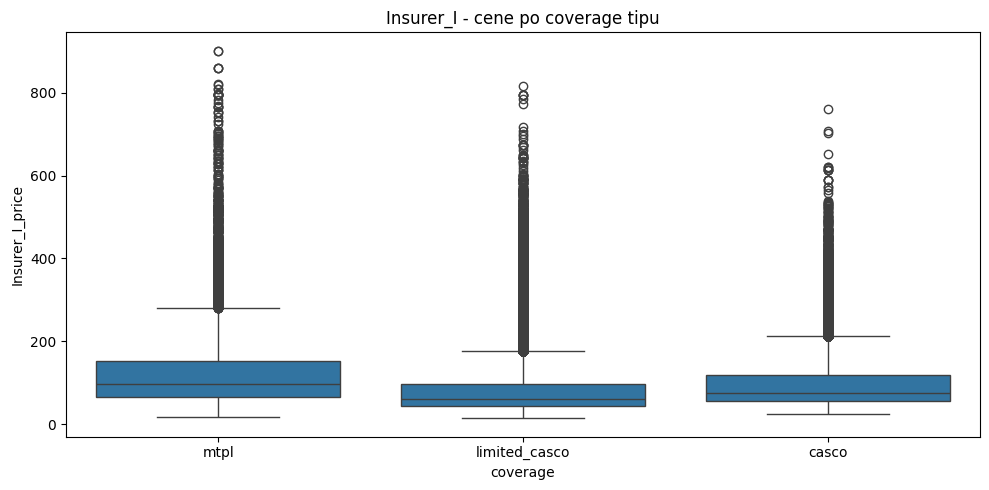

In [212]:
print("\n" + "="*80)
print("ANALIZA PO COVERAGE TIPU")
print("="*80)

if 'coverage' in data.columns:
    for insurer in target_insurers:
        price_col = f'{insurer}_price'
        if price_col in data.columns:
            print(f"\n{insurer}:")
            
            coverage_stats = data.groupby('coverage')[price_col].agg(['count', 'mean', 'median', 'std']).round(2)
            print(coverage_stats)
            
            # Vizuelizacija
            plt.figure(figsize=(10, 5))
            sns.boxplot(x='coverage', y=price_col, data=data)
            plt.title(f'{insurer} - cene po coverage tipu', fontsize=12)
            plt.tight_layout()
            plt.show()

In [ ]:
print("\n" + "="*80)
print("ZAKLJUČAK I PREPORUKE")
print("="*80)

print(f"""A
Na osnovu analize za {target_insurers}:

1. POTENCIJALNI PROBLEMI:
   - {'Visoka varijabilnost cena' if stats_df.loc[stats_df['insurer'].isin(target_insurers), 'cv'].mean() > 0.5 else 'Normalna varijabilnost'}
   - {'Malo feature-a sa jakom korelacijom' if len(corr_df[abs(corr_df['correlation']) > 0.2]) < 10 else 'Ima dovoljno jakih korelacija'}

2. KLJUČNI FEATURE-I ZA OVE OSIGURAVAČE:
   - {'coverage' if 'coverage' in corr_df['feature'].values else '...'}
   - {'claim_free_years' if 'claim_free_years' in corr_df['feature'].values else '...'}
   - {'vehicle_value_new' if 'vehicle_value_new' in corr_df['feature'].values else '...'}

3. PREPORUKE ZA POBOLJŠANJE MAE:
   a) Kreiraj specifične feature-e za ove osiguravače
   b) Probaj različite transformacije target-a (log, box-cox)
   c) Fokusiraj se na feature-e sa najvećom korelacijom
   d) Razmotri poseban model za ove osiguravače
""")


ZAKLJUČAK I PREPORUKE


NameError: name 'stats_df' is not defined

In [215]:
print("\n" + "="*80)
print("ANALIZA LOCATION FEATURE-A")
print("="*80)

# Location feature-i
location_features = [
    'province',
    'municipality',
    'postal_code',
    'postal_code_urban_category',
    'postal_code_population',
    'postal_code_address_density',
    'postal_code_average_property_value',
    'postal_code_distance_to_border',
    'postal_code_latitude',
    'postal_code_longitude',
    'municipality_crimes_per_1000'
]

# Dodaj urban score ako postoji
if 'urban_score_enhanced' in data.columns:
    location_features.append('urban_score_enhanced')
if 'log_urban_score' in data.columns:
    location_features.append('log_urban_score')

# Filtriraj postojeće
existing_location = [f for f in location_features if f in data.columns]

print(f"\nLocation feature-i za analizu: {existing_location[:10]}...")

for insurer in target_insurers:
    price_col = f'{insurer}_price'
    
    print(f"\n{'='*60}")
    print(f"{insurer} - KORELACIJE SA LOCATION FEATURE-IMA")
    print('='*60)
    
    location_corrs = []
    for feat in existing_location:
        if data[feat].dtype in ['int64', 'float64']:
            valid = data[[feat, price_col]].dropna()
            if len(valid) > 100:
                corr = valid[feat].corr(valid[price_col])
                location_corrs.append((feat, corr))
                if abs(corr) > 0.05:
                    print(f"  {feat:40} {corr:8.4f}")
    
    # Prosečna korelacija
    if location_corrs:
        avg_corr = np.mean([abs(c[1]) for c in location_corrs])
        print(f"\n  Prosečna apsolutna korelacija: {avg_corr:.4f}")


ANALIZA LOCATION FEATURE-A

Location feature-i za analizu: ['province', 'municipality', 'postal_code', 'postal_code_urban_category', 'postal_code_population', 'postal_code_address_density', 'postal_code_average_property_value', 'postal_code_distance_to_border', 'postal_code_latitude', 'postal_code_longitude']...

Insurer_E - KORELACIJE SA LOCATION FEATURE-IMA
  postal_code_urban_category                -0.1466
  postal_code_address_density                0.1194
  postal_code_average_property_value        -0.0553
  postal_code_latitude                      -0.0569
  postal_code_longitude                     -0.0945
  log_urban_score                            0.1898

  Prosečna apsolutna korelacija: 0.0886

Insurer_I - KORELACIJE SA LOCATION FEATURE-IMA
  postal_code_urban_category                -0.2808
  postal_code_address_density                0.2066
  postal_code_average_property_value        -0.1338
  postal_code_longitude                     -0.1417
  log_urban_score           


ANALIZA PO PROVINCIJAMA

Insurer_E - prosečne cene po provincijama:
province
12    131.73
6     126.73
8     121.73
10    113.49
2     111.89
9     109.68
7     108.38
4     102.99
5      96.61
11     96.02
1      93.55
3      91.52
Name: Insurer_E_price, dtype: float64


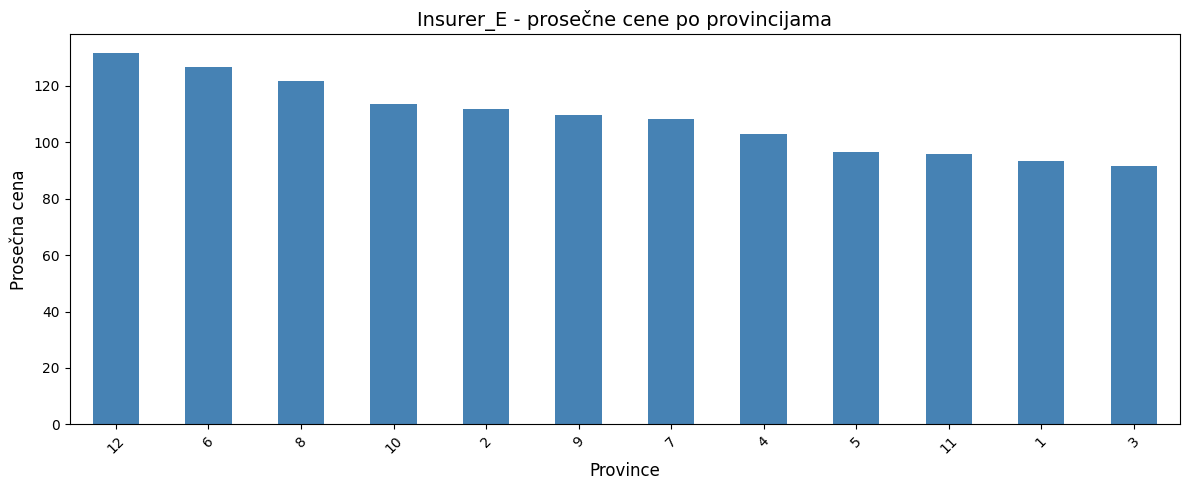


  ANOVA: F=713.34, p=0.0000e+00
  ✅ Province ZNAČAJNO utiču na cenu za Insurer_E

Insurer_I - prosečne cene po provincijama:
province
12    112.29
8     102.49
10     95.79
6      88.73
2      87.76
4      85.77
7      85.40
9      84.98
5      76.55
11     75.87
3      73.06
1      71.19
Name: Insurer_I_price, dtype: float64


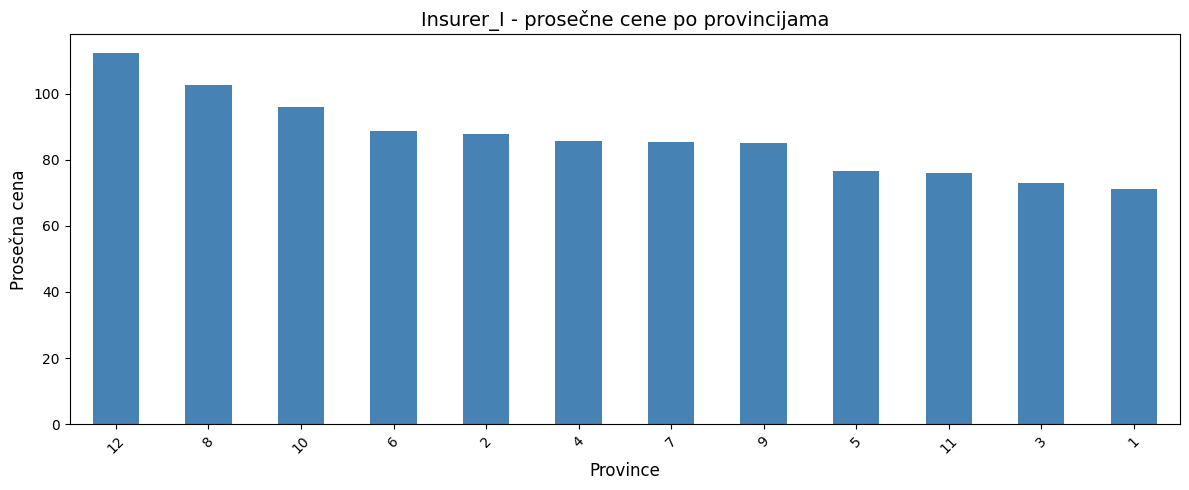


  ANOVA: F=826.34, p=0.0000e+00
  ✅ Province ZNAČAJNO utiču na cenu za Insurer_I


In [216]:
print("\n" + "="*80)
print("ANALIZA PO PROVINCIJAMA")
print("="*80)

if 'province' in data.columns:
    for insurer in target_insurers:
        price_col = f'{insurer}_price'
        
        print(f"\n{insurer} - prosečne cene po provincijama:")
        
        province_avg = data.groupby('province')[price_col].mean().sort_values(ascending=False)
        print(province_avg.round(2))
        
        # Vizuelizacija
        plt.figure(figsize=(12, 5))
        province_avg.plot(kind='bar', color='steelblue')
        plt.xlabel('Province', fontsize=12)
        plt.ylabel('Prosečna cena', fontsize=12)
        plt.title(f'{insurer} - prosečne cene po provincijama', fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # ANOVA test - da li province značajno utiču na cenu
        from scipy.stats import f_oneway
        
        groups = [data[data['province'] == p][price_col].dropna().values 
                  for p in data['province'].unique() if len(data[data['province'] == p][price_col].dropna()) > 10]
        
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            print(f"\n  ANOVA: F={f_stat:.2f}, p={p_value:.4e}")
            if p_value < 0.05:
                print(f"  ✅ Province ZNAČAJNO utiču na cenu za {insurer}")

PROVERA claim_free_years
Tip podataka: object
Prvih 10 vrednosti: ['2', '0', '5', '5', '3', '0', '0', '0', '0', '0']
Unique vrednosti (prvih 20): ['2' '0' '5' '3' '20' '1' '4' '15' '10' '30' '28' '7' '14' '19' '6' '24'
 '13' '8' '12' '-1']

ANALIZA PO CLAIM_FREE_YEARS (BONUS/MALUS)

Insurer_I:
           count    mean  median
cfy_group                       
-5 to -1    1262  103.66   91.54
0          68913  141.34  113.45
1-3        61597  112.05   86.52
4-7        56015   81.90   64.29
8-15       58030   61.32   52.39
15+        43612   58.11   50.67


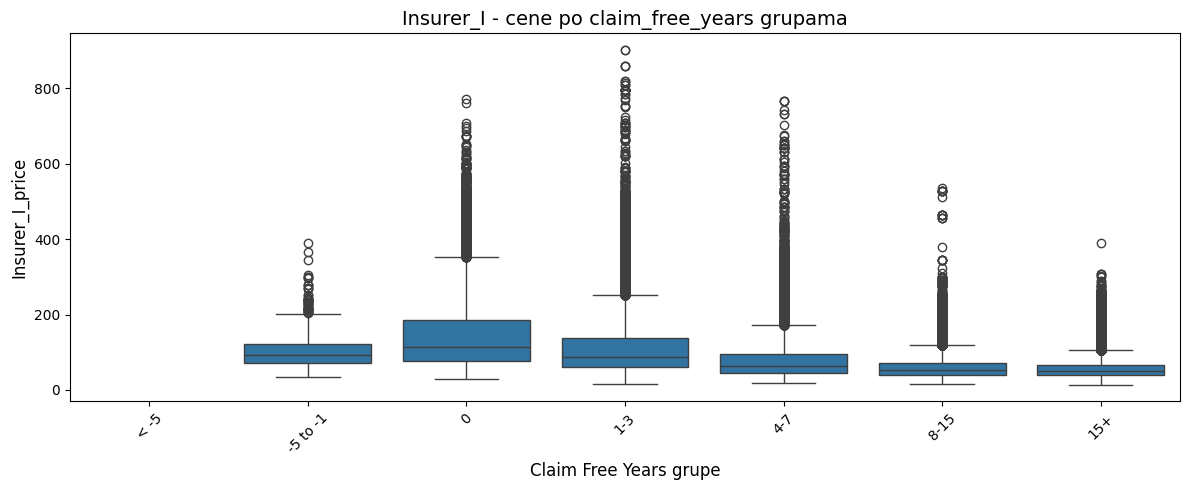


  Korelacija: -0.3510
  ✅ claim_free_years je VAŽAN za Insurer_I

Insurer_E:
            count    mean  median
cfy_group                        
-5 to -1     3691  151.28  130.78
0          116024  173.33  141.74
1-3         95958  118.32   98.47
4-7         73821   86.16   72.78
8-15        65274   74.83   64.74
15+         47788   69.44   60.41


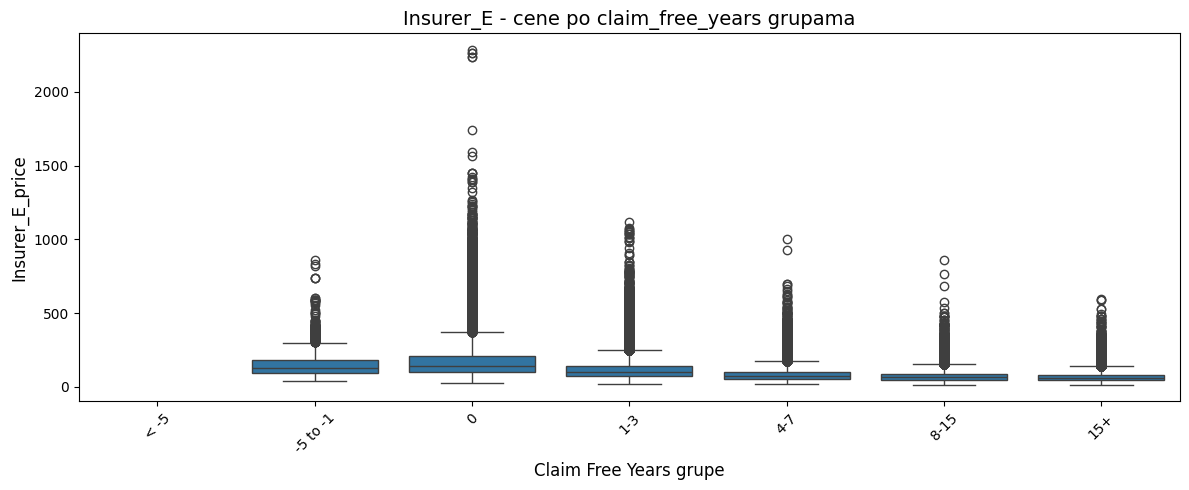


  Korelacija: -0.3336
  ✅ claim_free_years je VAŽAN za Insurer_E


In [219]:
print("="*80)
print("PROVERA claim_free_years")
print("="*80)
print(f"Tip podataka: {data['claim_free_years'].dtype}")
print(f"Prvih 10 vrednosti: {data['claim_free_years'].head(10).tolist()}")
print(f"Unique vrednosti (prvih 20): {data['claim_free_years'].unique()[:20]}")

# Konvertuj u numerički
data['claim_free_years'] = pd.to_numeric(data['claim_free_years'], errors='coerce')

target_insurers = ['Insurer_I', 'Insurer_E']
print("\n" + "="*80)
print("ANALIZA PO CLAIM_FREE_YEARS (BONUS/MALUS)")
print("="*80)

if 'claim_free_years' in data.columns:
    for insurer in target_insurers:
        price_col = f'{insurer}_price'
        
        print(f"\n{insurer}:")
        
        # Grupisanje
        data['cfy_group'] = pd.cut(data['claim_free_years'], 
                                    bins=[-100, -5, -1, 0, 3, 7, 15, 100],
                                    labels=['< -5', '-5 to -1', '0', '1-3', '4-7', '8-15', '15+'])
        
        cfy_stats = data.groupby('cfy_group')[price_col].agg(['count', 'mean', 'median']).round(2)
        print(cfy_stats)
        
        # Vizuelizacija
        plt.figure(figsize=(12, 5))
        sns.boxplot(x='cfy_group', y=price_col, data=data)
        plt.xlabel('Claim Free Years grupe', fontsize=12)
        plt.ylabel(price_col, fontsize=12)
        plt.title(f'{insurer} - cene po claim_free_years grupama', fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Korelacija
        valid = data[['claim_free_years', price_col]].dropna()
        corr = valid['claim_free_years'].corr(valid[price_col])
        print(f"\n  Korelacija: {corr:.4f}")
        if abs(corr) > 0.2:
            print(f"  ✅ claim_free_years je VAŽAN za {insurer}")
        else:
            print(f"  ⚠️ claim_free_years NIJE ključan za {insurer}")

In [220]:
if 'province' in data.columns:
    if data['province'].dtype == 'object':
        data['province'] = pd.to_numeric(data['province'], errors='coerce')
    
    print("="*80)
    print("KREIRANJE INTERAKCIJE: claim_free_years × province")
    print("="*80)
    
    # 1. Osnovna interakcija (proizvod)
    data['cfy_province_interaction'] = data['claim_free_years'] * data['province']
    print("✅ Kreiran: cfy_province_interaction")
    
    # 2. Interakcija sa apsolutnom vrednošću (magnituda bonus/malusa)
    data['cfy_abs_province'] = data['claim_free_years'].abs() * data['province']
    print("✅ Kreiran: cfy_abs_province")
    
    # 3. Interakcija sa znakom (bonus vs malus)
    data['cfy_sign'] = np.sign(data['claim_free_years'])
    data['cfy_sign_province'] = data['cfy_sign'] * data['province']
    print("✅ Kreiran: cfy_sign_province")

KREIRANJE INTERAKCIJE: claim_free_years × province
✅ Kreiran: cfy_province_interaction
✅ Kreiran: cfy_abs_province
✅ Kreiran: cfy_sign_province


In [221]:
print("\n" + "="*80)
print("PROVINCE-SPECIFIC TRANSFORMACIJE")
print("="*80)

# Za svaku provinciju posebno, normalizuj claim_free_years
if 'province' in data.columns:
    # 1. Standardizacija unutar svake provincije
    data['cfy_standardized_by_province'] = data.groupby('province')['claim_free_years'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x
    )
    print("✅ Kreiran: cfy_standardized_by_province")
    
    # 2. Rank unutar provincije
    data['cfy_rank_by_province'] = data.groupby('province')['claim_free_years'].rank(pct=True)
    print("✅ Kreiran: cfy_rank_by_province")
    
    # 3. Kategorije unutar provincije (top 25%, bottom 25% itd.)
    data['cfy_quartile_by_province'] = data.groupby('province')['claim_free_years'].transform(
        lambda x: pd.qcut(x, q=4, labels=['Q1 (najgori)', 'Q2', 'Q3', 'Q4 (najbolji)'], duplicates='drop')
    )
    print("✅ Kreiran: cfy_quartile_by_province")


PROVINCE-SPECIFIC TRANSFORMACIJE
✅ Kreiran: cfy_standardized_by_province
✅ Kreiran: cfy_rank_by_province
✅ Kreiran: cfy_quartile_by_province


In [222]:
print("\n" + "="*80)
print("KOMBINOVANI RISK SCORE")
print("="*80)

# Kombinuj claim_free_years i province u jedan score
# (veći score = veći rizik = viša cena)

# 1. Invertuj claim_free_years (manje godina = veći rizik)
# claim_free_years: što manje (ili negativnije) = lošiji vozač
data['cfy_risk'] = -data['claim_free_years']  # negativno postaje pozitivno

# Normalizuj na 0-1
cfy_min = data['cfy_risk'].min()
cfy_max = data['cfy_risk'].max()
data['cfy_risk_norm'] = (data['cfy_risk'] - cfy_min) / (cfy_max - cfy_min)

# 2. Province risk (ako imaš prosečne cene po provinciji)
province_avg_risk = data.groupby('province')['Insurer_E_price'].mean()  # ili I
data['province_risk'] = data['province'].map(province_avg_risk)

# Normalizuj province risk
province_min = province_avg_risk.min()
province_max = province_avg_risk.max()
data['province_risk_norm'] = (data['province_risk'] - province_min) / (province_max - province_min)

# 3. Kombinovani score (možeš menjati težine)
data['combined_risk_score'] = data['cfy_risk_norm'] * 0.6 + data['province_risk_norm'] * 0.4
print("✅ Kreiran: combined_risk_score (60% CFY, 40% Province)")

# 4. Interakcijski score (proizvod)
data['interaction_risk_score'] = data['cfy_risk_norm'] * data['province_risk_norm']
print("✅ Kreiran: interaction_risk_score")


KOMBINOVANI RISK SCORE
✅ Kreiran: combined_risk_score (60% CFY, 40% Province)
✅ Kreiran: interaction_risk_score



ANALIZA ZA Insurer_E


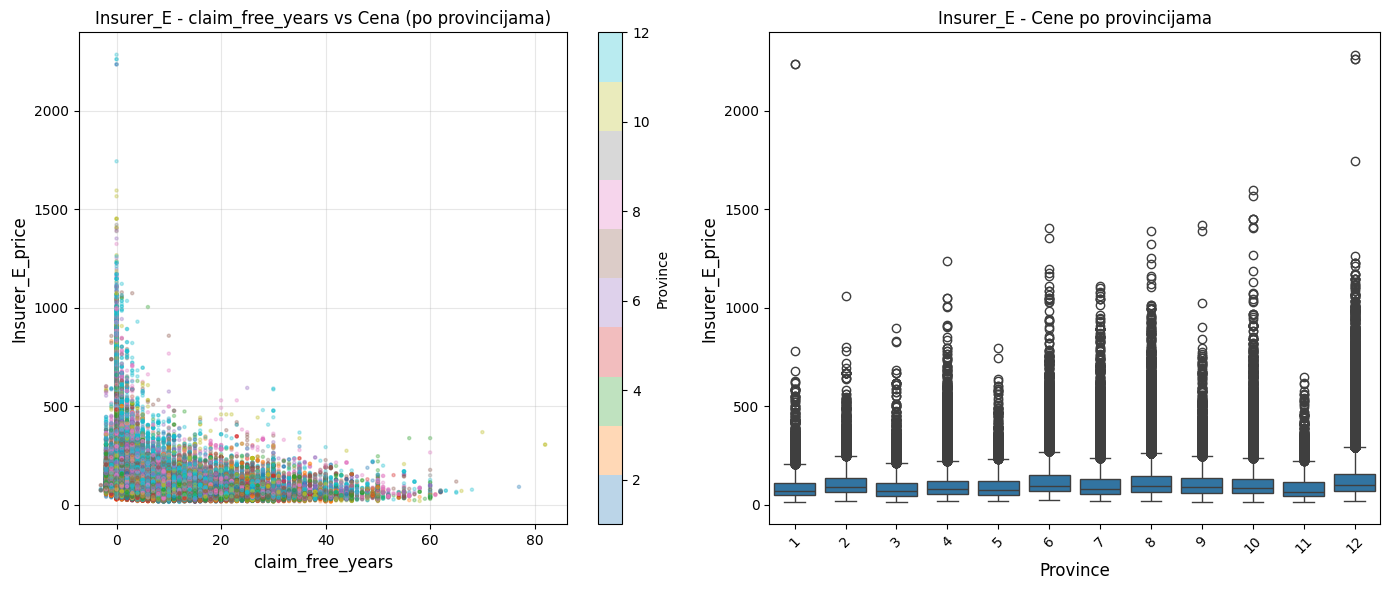


Korelacije novih feature-a sa Insurer_E:
  cfy_province_interaction             -0.2856
  cfy_standardized_by_province         -0.3308
  combined_risk_score                   0.2636
  interaction_risk_score                0.2051

ANALIZA ZA Insurer_I


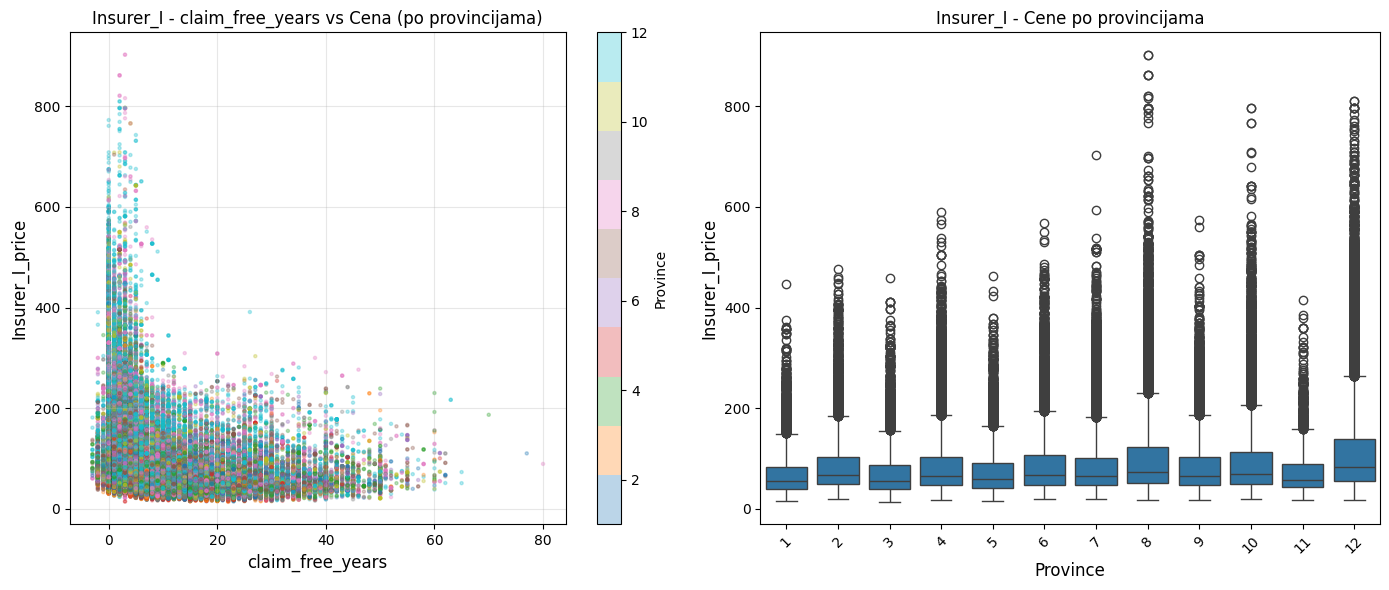


Korelacije novih feature-a sa Insurer_I:
  cfy_province_interaction             -0.2917
  cfy_standardized_by_province         -0.3466
  combined_risk_score                   0.2948
  interaction_risk_score                0.2371


In [223]:
target_insurers = ['Insurer_E', 'Insurer_I']

for insurer in target_insurers:
    price_col = f'{insurer}_price'
    
    print(f"\n{'='*80}")
    print(f"ANALIZA ZA {insurer}")
    print('='*80)
    
    # 1. Scatter plot: claim_free_years vs cena, obojeno po provinciji
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(data['claim_free_years'], data[price_col], 
                          c=data['province'], cmap='tab10', alpha=0.3, s=5)
    plt.colorbar(scatter, label='Province')
    plt.xlabel('claim_free_years', fontsize=12)
    plt.ylabel(price_col, fontsize=12)
    plt.title(f'{insurer} - claim_free_years vs Cena (po provincijama)', fontsize=12)
    plt.grid(alpha=0.3)
    
    # 2. Box plot po provincijama
    plt.subplot(1, 2, 2)
    sns.boxplot(x='province', y=price_col, data=data)
    plt.xlabel('Province', fontsize=12)
    plt.ylabel(price_col, fontsize=12)
    plt.title(f'{insurer} - Cene po provincijama', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Korelacije novih feature-a
    new_features = ['cfy_province_interaction', 'cfy_standardized_by_province', 
                    'combined_risk_score', 'interaction_risk_score']
    
    print(f"\nKorelacije novih feature-a sa {insurer}:")
    for feat in new_features:
        if feat in data.columns:
            valid = data[[feat, price_col]].dropna()
            if len(valid) > 100:
                corr = valid[feat].corr(valid[price_col])
                print(f"  {feat:35} {corr:8.4f}")

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nova 4 feature-a
new_features = [
    'cfy_province_interaction',
    'cfy_standardized_by_province',
    'combined_risk_score',
    'interaction_risk_score'
]

# Cene
price_cols = [col for col in data.columns if col.endswith('_price')]
insurers = [col.replace('_price', '') for col in price_cols]

print("="*80)
print("KORELACIJE NOVIH FEATURE-A SA CENAMA OSIGURAVAČA")
print("="*80)

# Izračunaj korelacije
results = []

for insurer in insurers:
    price_col = f'{insurer}_price'
    row = {'insurer': insurer}
    
    for feat in new_features:
        if feat in data.columns:
            valid = data[[feat, price_col]].dropna()
            if len(valid) > 100:
                row[feat] = valid[feat].corr(valid[price_col])
            else:
                row[feat] = np.nan
        else:
            row[feat] = np.nan
    
    results.append(row)

# Pretvori u DataFrame
corr_df = pd.DataFrame(results)

# Sortiraj po nekom feature-u (npr. po combined_risk_score)
corr_df = corr_df.sort_values('combined_risk_score', ascending=False)

print("\n" + "="*80)
print("TABELA KORELACIJA")
print("="*80)
print(corr_df.round(4).to_string(index=False))

KORELACIJE NOVIH FEATURE-A SA CENAMA OSIGURAVAČA

TABELA KORELACIJA
  insurer  cfy_province_interaction  cfy_standardized_by_province  combined_risk_score  interaction_risk_score
Insurer_F                   -0.3678                       -0.4240               0.3053                  0.2214
Insurer_C                   -0.2872                       -0.3441               0.3011                  0.2432
Insurer_I                   -0.2917                       -0.3466               0.2948                  0.2371
Insurer_J                   -0.3411                       -0.4000               0.2937                  0.2178
Insurer_B                   -0.3357                       -0.3898               0.2901                  0.2187
Insurer_D                   -0.3457                       -0.4017               0.2900                  0.2135
Insurer_K                   -0.3734                       -0.4318               0.2886                  0.2050
Insurer_G                   -0.3101         

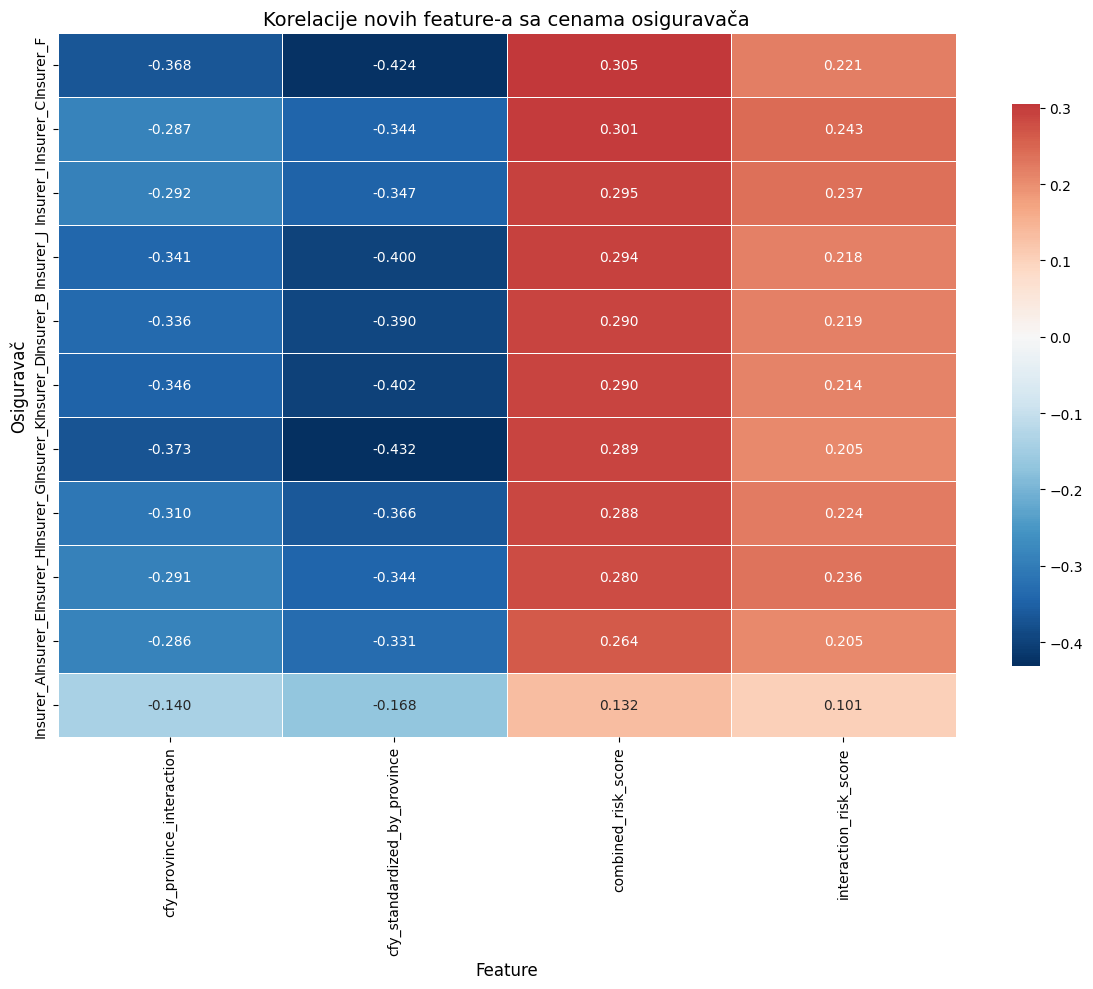

In [225]:
# Pripremi podatke za heatmap
heatmap_data = corr_df.set_index('insurer')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Korelacije novih feature-a sa cenama osiguravača', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Osiguravač', fontsize=12)
plt.tight_layout()
plt.show()